# Imports

In [ ]:
# Linear algebra
import numpy as np

# Dataframes
import pandas as pd

# Path
import os
data_path = os.path.join('..', 'data')
virus_data_path = os.path.join('..', 'data', 'human_viruses')
virus_results_path = os.path.join(data_path, 'Results', 'human_viruses')

# Json
import json

# Plotting
# import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize

# Gaussian smoothing
from scipy.ndimage import gaussian_filter1d
# Interactive plotting
from plotly.graph_objs import *
import plotly.graph_objs as go

# Bio
from Bio.Seq import Seq
from Bio.Data import CodonTable
from Bio import Entrez

# statistis
from scipy.stats import entropy

# Progress bar
from tqdm import tqdm

# Load Data

In [2]:
human_viruses = pd.read_pickle(os.path.join(virus_data_path, 'human_viruses.pkl'))

virus_eval_mfc = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_mfc.csv'))

virus_eval_mfb = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_mfb.csv'))

virus_eval_ablation = pd.read_csv(os.path.join(virus_results_path, 'virus_ablation_evaluation.csv'))

virus_eval_bart30 = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_none_expression.csv'))
# virus_eval_random = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_random_expression.csv'))

# virus_eval_low = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_low_expression.csv'))
# virus_eval_medium_low = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_medium_low_expression.csv'))
# virus_eval_medium_high = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_medium_high_expression.csv'))
# virus_eval_high = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_high_expression.csv'))

# virus_eval_naive_aligned = pd.read_csv(os.path.join(virus_results_path, 'virus_evaluation_naive_aligned_expression.csv'))
# virus_eval_naive_aligned_1 = pd.read_csv('virus_evaluation_naive_aligned_1_expression.csv')

# merge predictions with human viruses
# virus_eval_mfc.drop(['Unnamed: 0'], axis=1, inplace=True)
virus_eval_mfc.rename(columns={'mfc_prediction': 'mfc_predicted_codons'}, inplace=True)

# virus_eval_mfb.drop(['Unnamed: 0'], axis=1, inplace=True)
virus_eval_mfb.rename(columns={'mfb_prediction': 'mfb_predicted_codons'}, inplace=True)

virus_eval_ablation.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
virus_eval_ablation.rename(columns={'predicted_codons': 'bart30_ablation_predicted_codons',
                                'entropy': 'bart30_ablation_entropy',
                                'num_of_correct_predicted_codons': 'bart30_ablation_num_of_correct_predicted_codons',
                                'cross_entropy_loss': 'bart30_ablation_cross_entropy_loss',
                                'perplexity': 'bart30_ablation_perplexity',
                                'accuracy': 'bart30_ablation_accuracy'}, inplace=True)

virus_eval_bart30.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
virus_eval_bart30.rename(columns={'predicted_codons': 'bart30_predicted_codons',
                                'entropy': 'bart30_entropy',
                                'num_of_correct_predicted_codons': 'bart30_num_of_correct_predicted_codons',
                                'cross_entropy_loss': 'bart30_cross_entropy_loss',
                                'perplexity': 'bart30_perplexity',
                                'accuracy': 'bart30_accuracy'}, inplace=True)

# virus_eval_random.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
# virus_eval_random.rename(columns={'predicted_codons': 'random_predicted_codons',
#                                     'entropy': 'random_entropy',
#                                     'num_of_correct_predicted_codons': 'random_num_of_correct_predicted_codons',
#                                     'cross_entropy_loss': 'random_cross_entropy_loss',
#                                     'perplexity': 'random_perplexity',
#                                     'accuracy': 'random_accuracy'}, inplace=True)

# virus_eval_low.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
# virus_eval_low.rename(columns={'predicted_codons': 'low_predicted_codons',
#                                 'entropy': 'low_entropy',
#                                 'num_of_correct_predicted_codons': 'low_num_of_correct_predicted_codons',
#                                 'cross_entropy_loss': 'low_cross_entropy_loss',
#                                 'perplexity': 'low_perplexity',
#                                 'accuracy': 'low_accuracy'}, inplace=True)

# virus_eval_medium_low.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
# virus_eval_medium_low.rename(columns={'predicted_codons': 'medium_low_predicted_codons',
#                                       'entropy': 'medium_low_entropy',
#                                       'num_of_correct_predicted_codons': 'medium_low_num_of_correct_predicted_codons',
#                                       'cross_entropy_loss': 'medium_low_cross_entropy_loss',
#                                       'perplexity': 'medium_low_perplexity',
#                                       'accuracy': 'medium_low_accuracy'}, inplace=True)

# virus_eval_medium_high.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
# virus_eval_medium_high.rename(columns={'predicted_codons': 'medium_high_predicted_codons',
#                                        'entropy': 'medium_high_entropy',
#                                        'num_of_correct_predicted_codons': 'medium_high_num_of_correct_predicted_codons',
#                                        'cross_entropy_loss': 'medium_high_cross_entropy_loss',
#                                        'perplexity': 'medium_high_perplexity',
#                                        'accuracy': 'medium_high_accuracy'}, inplace=True)

# virus_eval_high.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
# virus_eval_high.rename(columns={'predicted_codons': 'high_predicted_codons',
#                                 'entropy': 'high_entropy',
#                                 'num_of_correct_predicted_codons': 'high_num_of_correct_predicted_codons',
#                                 'cross_entropy_loss': 'high_cross_entropy_loss',
#                                 'perplexity': 'high_perplexity',
#                                 'accuracy': 'high_accuracy'}, inplace=True)

# virus_eval_naive_aligned.drop(['inx', 'protein_len', 'protein_AAs', 'protein_codons'], axis=1, inplace=True)
# virus_eval_naive_aligned.rename(columns={'predicted_codons': 'naive_aligned_predicted_codons',
#                                          'entropy': 'naive_aligned_entropy',
#                                          'num_of_correct_predicted_codons': 'naive_aligned_num_of_correct_predicted_codons',
#                                          'cross_entropy_loss': 'naive_aligned_cross_entropy_loss',
#                                          'perplexity': 'naive_aligned_perplexity',
#                                          'accuracy': 'naive_aligned_accuracy'}, inplace=True)

human_viruses = human_viruses.merge(virus_eval_bart30, on='Protein.ID', how='left')
human_viruses = human_viruses.merge(virus_eval_ablation, on='Protein.ID', how='left')
human_viruses = human_viruses.merge(virus_eval_mfc, left_index=True, right_on='Unnamed: 0', how='left')
human_viruses = human_viruses.merge(virus_eval_mfb, left_index=True, right_on='Unnamed: 0', how='left')
# human_viruses = human_viruses.merge(virus_eval_random, on='Protein.ID', how='left')
# human_viruses = human_viruses.merge(virus_eval_low, on='Protein.ID', how='left')
# human_viruses = human_viruses.merge(virus_eval_medium_low, on='Protein.ID', how='left')
# human_viruses = human_viruses.merge(virus_eval_medium_high, on='Protein.ID', how='left')
# human_viruses = human_viruses.merge(virus_eval_high, on='Protein.ID', how='left')
# human_viruses = human_viruses.merge(virus_eval_naive_aligned, on='Protein.ID', how='left')

human_viruses.drop(['Unnamed: 0', 'Unnamed: 0_x', 'Unnamed: 0_y'], axis=1, inplace=True)

In [3]:
coronavirus_2_mask = human_viruses['Species'].apply(lambda x: 'coronavirus 2' in x)

human_viruses[coronavirus_2_mask]

,Protein.ID,Accession,VOG,annotation,Division,Taxid,Species,Organelle,X..Codons,GC.,...,bart30_ablation_predicted_codons,bart30_ablation_entropy,bart30_ablation_num_of_correct_predicted_codons,bart30_ablation_cross_entropy_loss,bart30_ablation_perplexity,bart30_ablation_accuracy,mfc_predicted_codons,mfc_accuracy,mfb_predicted_codons,mfb_accuracy
2198,NP_073549,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,6759,37.830000,...,ATG GCC TGC AAC CGG GTG ACC CTG GCT GTG GCC AG...,-4285.119141,2533,1.176266,3.242245,0.374760,ATGGCCTGCAACAGAGTGACCCTGGCCGTGGCCAGCGACAGCGAGA...,0.239385,ATGGCCTGCAACAGAGTGACCCTGGCCGTGGCCAGCGACAGCGAGA...,0.248705
2199,NP_073550,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,4086,37.640000,...,ATG GCC TGC AAC CGG GTG ACC CTG GCT GTG GCC AG...,-4277.036621,1537,1.174843,3.237634,0.376163,ATGGCCTGCAACAGAGTGACCCTGGCCGTGGCCAGCGACAGCGAGA...,0.229320,ATGGCCTGCAACAGAGTGACCCTGGCCGTGGCCAGCGACAGCGAGA...,0.237151
2200,NP_073551,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,1174,38.870000,...,ATG TTT GTG CTG CTG GTG GCC TAT GCC CTG CTG CA...,-4179.105469,417,1.212183,3.360813,0.355196,ATGTTCGTGCTGCTGGTGGCCTACGCCCTGCTGCACATCGCCGGCT...,0.237649,ATGTTTGTGCTGCTGGTGGCCTACGCCCTGCTGCACATCGCCGGCT...,0.242760
2201,NP_073552,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,134,39.300000,...,ATG GCC CTG GGC CTC TTC ACC CTG CAG CTG GTG TC...,-4156.326172,50,1.285439,3.616253,0.373134,ATGGCCCTGGGCCTGTTCACCCTGCAGCTGGTGAGCGCCGTGAACC...,0.291045,ATGGCCCTGGGCCTGTTCACCCTGCAGCTGGTGTCCGCCGTGAACC...,0.291045
2202,NP_073553,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,89,37.080000,...,ATG CAA GGA AAG TGC TGG TTC CTG GAA AAC AAG GC...,-4342.687012,32,1.174912,3.237857,0.359551,ATGCAGGGCAAGTGCTGGTTCCTGGAGAACAAGGCCCTGAAGCCCT...,0.325843,ATGCAGGGCAAGTGCTGGTTTCTGGAGAACAAGGCCCTGAAGCCCT...,0.314607
2203,NP_073554,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,78,33.330000,...,ATG TTC CTG AAG CTG GTG GAT GAC CAT GCC CTG GT...,-4425.027832,30,1.151188,3.161948,0.384615,ATGTTCCTGAAGCTGGTGGACGACCACGCCCTGGTGGTGAACGTGC...,0.320513,ATGTTTCTGAAGCTGGTGGACGACCACGCCCTGGTGGTGAACGTGC...,0.358974
2204,NP_073555,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,226,41.590000,...,ATG AGC AAT GAC AAC TGC ACT GGA GAC ATT GTG AC...,-4323.186523,80,1.256418,3.512815,0.353982,ATGAGCAACGACAACTGCACCGGCGACATCGTGACCCACCTGAAGA...,0.358407,ATGAGCAACGACAACTGCACCGGCGACATCGTGACCCACCTGAAGA...,0.331858
2205,NP_073556,NC_002645,NaN,NaN,refseq,11137,Human coronavirus 229E,genomic,390,43.590000,...,ATG GCC ACA GTG AAG TGG GCG GAT GCC TCA GAG CC...,-4113.049316,147,1.183767,3.266656,0.376923,ATGGCCACCGTGAAGTGGGCCGACGCCAGCGAGCCCCAGAGAGGCA...,0.261538,ATGGCCACCGTGAAGTGGGCCGACGCCAGCGAGCCCCAGAGGGGCC...,0.251282
5078,YP_009724389,NC_045512,NaN,NaN,refseq,2697049,Severe acute respiratory syndrome coronavirus 2,genomic,7097,37.457142,...,ATG GAG AGC CTG GTG CCT GGC TTC AAT GAG AAG AC...,-4253.012207,2573,1.197035,3.310287,0.362548,ATGGAGAGCCTGGTGCCCGGCTTCAACGAGAAGACCCACGTGCAGC...,0.230238,ATGGAGAGCCTGGTGCCCGGCTTCAACGAGAAGACCCACGTGCAGC...,0.239961
5079,YP_009725295,NC_045512,NaN,NaN,refseq,2697049,Severe acute respiratory syndrome coronavirus 2,genomic,4406,37.728855,...,ATG GAG AGC CTG GTG CCT GGC TTC AAT GAG AAG AC...,-4232.136230,1590,1.202947,3.329915,0.360872,ATGGAGAGCCTGGTGCCCGGCTTCAACGAGAAGACCCACGTGCAGC...,0.230368,ATGGAGAGCCTGGTGCCCGGCTTCAACGAGAAGACCCACGTGCAGC...,0.235815


# Graph Accuracies

## Histograms

In [6]:
nan_indices = human_viruses[human_viruses['tropism'].isna()].index

In [7]:
temp = human_viruses.dropna(subset=['annotation'])

Xr_indices = temp[temp['annotation'].apply(lambda x: 'Xu' in x).tolist()].index

Xs_indices = temp[temp['annotation'].apply(lambda x: 'Xh' in x).tolist()].index

In [8]:
virus_eval_naive = pd.read_csv('virus_evaluation_naive_aligned_expression.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'virus_evaluation_naive_aligned_expression.csv'

In [ ]:
print(virus_eval_naive.loc[nan_indices]['accuracy'].mean())
print(virus_eval_naive.drop(nan_indices)['accuracy'].mean())

0.3583352272854062
0.3818670113607647


In [ ]:
print(virus_eval_naive.loc[Xr_indices]['accuracy'].mean())
print(virus_eval_naive.loc[Xs_indices]['accuracy'].mean())

0.36567158642773623
0.360432528351759


In [ ]:
virus_eval_naive.loc[:, 'accuracy'].mean()

np.float64(0.37941961198691954)

In [ ]:
virus_eval_naive

In [ ]:
virus_eval_naive['accuracy'].mean()

np.float64(0.37941961198691954)

In [ ]:
virus_eval_high = pd.read_csv('virus_evaluation_high_expression.csv')

In [ ]:
virus_eval_high.loc[:, 'accuracy'].mean()

np.float64(0.38641724025174073)

In [ ]:
virus_eval_none.loc[Xs_indices]['accuracy'].mean()

np.float64(0.3892108017726763)

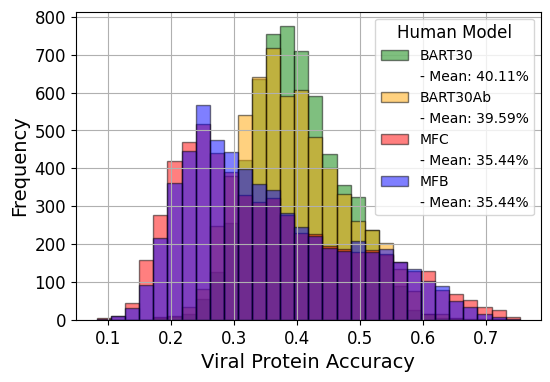

In [39]:
# plot virus_eval_none, virus_eval_naive, virus_eval_high accuracies overlayed on a histogram
# add legend

plt.figure(figsize=(6, 4))

# Calculate shared bins
all_accuracies = pd.concat([
    human_viruses['mfc_accuracy'],
    human_viruses['mfb_accuracy'],
    human_viruses['bart30_accuracy']
])
bins = np.histogram_bin_edges(all_accuracies, bins=30)

# Plot histograms with shared bins
plt.hist(human_viruses['bart30_accuracy'], bins=bins, color='green', alpha=0.5, label='BART30', edgecolor='black')
plt.axvline(human_viruses['bart30_accuracy'].mean(), color='green', linestyle='dashed', linewidth=1, label=f"- Mean: {human_viruses['bart30_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(human_viruses['bart30_accuracy'].std(), color='green', linestyle='dashdot', linewidth=1, label=f"- Std: {human_viruses['bart30_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.hist(human_viruses['bart30_ablation_accuracy'], bins=bins, color='orange', alpha=0.5, label='BART30Ab', edgecolor='black')
plt.axvline(human_viruses['bart30_ablation_accuracy'].mean(), color='orange', linestyle='dashed', linewidth=1, label=f"- Mean: {human_viruses['bart30_ablation_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(human_viruses['bart30_ablation_accuracy'].std(), color='orange', linestyle='dashdot', linewidth=1, label=f"- Std: {human_viruses['bart30_ablation_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.hist(human_viruses['mfc_accuracy'], bins=bins, color='red', alpha=0.5, label='MFC', edgecolor='black')
plt.axvline(human_viruses['mfc_accuracy'].mean(), color='red', linestyle='dashed', linewidth=1, label=f"- Mean: {human_viruses['mfc_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(human_viruses['mfc_accuracy'].std(), color='red', linestyle='dashdot', linewidth=1, label=f"- Std: {human_viruses['mfc_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.hist(human_viruses['mfb_accuracy'], bins=bins, color='blue', alpha=0.5, label='MFB', edgecolor='black')
plt.axvline(human_viruses['mfb_accuracy'].mean(), color='blue', linestyle='dashed', linewidth=1, label=f"- Mean: {human_viruses['mfb_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(human_viruses['mfb_accuracy'].std(), color='blue', linestyle='dashdot', linewidth=1, label=f"- Std: {human_viruses['mfb_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.legend(loc='upper right', title='Human Model', fontsize=10, title_fontsize=12)
plt.grid(True)

plt.xlabel('Viral Protein Accuracy', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('viral_proteins_accuracy_histogram.svg', format='svg', bbox_inches='tight')

plt.show()

In [13]:
# Calculate the codon counts (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)

# Calculate the weighted means for each group and model
virus_mean_accuracies = human_viruses.groupby('Species')[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy', 'codon_count']].apply(
    lambda group: pd.Series({
        'mfc_accuracy': np.average(group['mfc_accuracy'], weights=group['codon_count']),
        'mfb_accuracy': np.average(group['mfb_accuracy'], weights=group['codon_count']),
        'bart30_ablation_accuracy': np.average(group['bart30_ablation_accuracy'], weights=group['codon_count']),
        'bart30_accuracy': np.average(group['bart30_accuracy'], weights=group['codon_count'])
    })
)

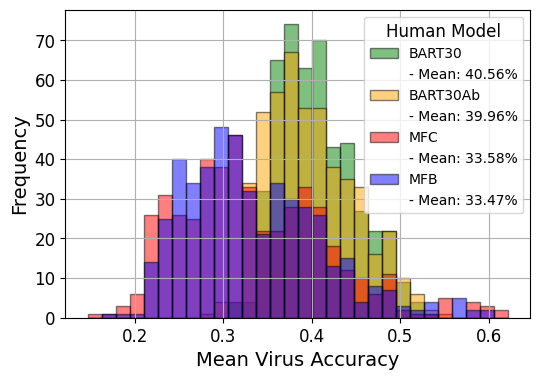

In [40]:
# Plot virus_mean_accuracies overlayed on a histogram
plt.figure(figsize=(6, 4))

# Calculate shared bins
all_accuracies = pd.concat([
    virus_mean_accuracies['mfc_accuracy'],
    virus_mean_accuracies['mfb_accuracy'],
    virus_mean_accuracies['bart30_ablation_accuracy'],
    virus_mean_accuracies['bart30_accuracy']
])
bins = np.histogram_bin_edges(all_accuracies, bins=30)

# Plot histograms with shared bins
plt.hist(virus_mean_accuracies['bart30_accuracy'], bins=bins, color='green', alpha=0.5, label='BART30', edgecolor='black')
plt.axvline(virus_mean_accuracies['bart30_accuracy'].mean(), color='green', linestyle='dashed', linewidth=1, label=f"- Mean: {virus_mean_accuracies['bart30_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(virus_mean_accuracies['bart30_accuracy'].std(), color='green', linestyle='dashdot', linewidth=1, label=f"- Std: {virus_mean_accuracies['bart30_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.hist(virus_mean_accuracies['bart30_ablation_accuracy'], bins=bins, color='orange', alpha=0.5, label='BART30Ab', edgecolor='black')
plt.axvline(virus_mean_accuracies['bart30_ablation_accuracy'].mean(), color='orange', linestyle='dashed', linewidth=1, label=f"- Mean: {virus_mean_accuracies['bart30_ablation_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(virus_mean_accuracies['bart30_ablation_accuracy'].std(), color='orange', linestyle='dashdot', linewidth=1, label=f"- Std: {virus_mean_accuracies['bart30_ablation_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.hist(virus_mean_accuracies['mfc_accuracy'], bins=bins, color='red', alpha=0.5, label='MFC', edgecolor='black')
plt.axvline(virus_mean_accuracies['mfc_accuracy'].mean(), color='red', linestyle='dashed', linewidth=1, label=f"- Mean: {virus_mean_accuracies['mfc_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(virus_mean_accuracies['mfc_accuracy'].std(), color='red', linestyle='dashdot', linewidth=1, label=f"- Std: {virus_mean_accuracies['mfc_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.hist(virus_mean_accuracies['mfb_accuracy'], bins=bins, color='blue', alpha=0.5, label='MFB', edgecolor='black')
plt.axvline(virus_mean_accuracies['mfb_accuracy'].mean(), color='blue', linestyle='dashed', linewidth=1, label=f"- Mean: {virus_mean_accuracies['mfb_accuracy'].mean() * 100 :.2f}%", alpha=0)
# plt.axvline(virus_mean_accuracies['mfb_accuracy'].std(), color='blue', linestyle='dashdot', linewidth=1, label=f"- Std: {virus_mean_accuracies['mfb_accuracy'].std() * 100 :.2f}%", alpha=0)

plt.legend(loc='upper right', title='Human Model', fontsize=10, title_fontsize=12)
plt.grid(True)

plt.xlabel('Mean Virus Accuracy', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Dynamically set x-axis limits based on data
plt.xlim(all_accuracies.min() - 0.025, all_accuracies.max() + 0.025)

plt.savefig('virus_mean_accuracies_histogram.svg', format='svg', bbox_inches='tight')

plt.show()


## Mean Virus Accuracy vs DKL

**Human Codon Bias**

In [4]:
codon_to_fraction_path = os.path.join(data_path, 'Results',  "codon_to_fraction.npy")

# load .npy dictionary
codon_to_fraction = np.load(codon_to_fraction_path, allow_pickle=True).item()

# convert dictionary to DataFrame
codon_to_fraction_df = pd.DataFrame.from_dict(codon_to_fraction, orient='index', columns=['Fraction'])

**Accuracy per virus**

In [5]:
# Calculate the codon counts (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)
human_viruses['Host'] = human_viruses['Host'].apply(lambda x: ['Human'] if np.all(pd.isna(x)) else x)

# Calculate the weighted means for each group and model, and add a column for the number of rows in each group
virus_mean_accuracies = human_viruses.groupby('Species')[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy', 'codon_count', 'tropism', 'Host']].apply(
    lambda group: pd.Series({
        'mfc_accuracy': np.average(group['mfc_accuracy'], weights=group['codon_count']),
        'mfb_accuracy': np.average(group['mfb_accuracy'], weights=group['codon_count']),
        'bart30_ablation_accuracy': np.average(group['bart30_ablation_accuracy'], weights=group['codon_count']),
        'bart30_accuracy': np.average(group['bart30_accuracy'], weights=group['codon_count']),
        'num_rows': len(group),
        'tropism': group['tropism'].iloc[0],
        'Host': group['Host'].iloc[0]
    })
)

**Virus Codon Biases**

In [6]:
# concatenate all sequences of the same species
species_aggregated_dna = human_viruses.groupby('Species')['codon_seq'].agg(lambda x: ''.join(x))

In [7]:
# Get the standard codon table
codon_table = CodonTable.unambiguous_dna_by_name['Standard']
# Include stop codons
codon_table.stop_codons = {'TAA', 'TAG', 'TGA'}

# Function to calculate codon fractions
def calculate_codon_fractions(sequence):
    global codon_table
    
    codon_counts = {}
    total_codons = len(sequence) // 3
    for i in range(0, len(sequence) - 2, 3):
        codon = sequence[i:i+3]
        if codon in codon_table.forward_table or codon in codon_table.stop_codons:
            codon_counts[codon] = codon_counts.get(codon, 0) + 1
    return {codon: count / total_codons for codon, count in codon_counts.items()}

# Function to calculate KL divergence for synonymous codons of each amino acid
def calculate_kl_divergence(codon_fractions, mean_codon_fractions):
    global codon_table
    
    kl_divergences = {}
    # Reverse the mapping to group codons by their respective amino acids
    amino_acid_to_codons = {}
    for codon, amino_acid in codon_table.forward_table.items():
        if amino_acid not in amino_acid_to_codons:
            amino_acid_to_codons[amino_acid] = []
        amino_acid_to_codons[amino_acid].append(codon)

    for amino_acid, codons in amino_acid_to_codons.items():
        # Include stop codons
        if amino_acid == '*':
            codons = codon_table.stop_codons
        # Get the distributions for the synonymous codons
        codon_dist = [codon_fractions.get(codon, 0) for codon in codons]
        mean_dist = [mean_codon_fractions.get(codon, 0) for codon in codons]
        # Normalize distributions to ensure they sum to 1
        codon_dist = np.array(codon_dist) / np.sum(codon_dist) if np.sum(codon_dist) > 0 else np.zeros(len(codon_dist))
        mean_dist = np.array(mean_dist) / np.sum(mean_dist) if np.sum(mean_dist) > 0 else np.zeros(len(mean_dist))
        # Calculate KL divergence
        kl_divergences[amino_acid] = entropy(codon_dist, mean_dist)
    return kl_divergences

amino_acids = sorted(list(set(codon_table.forward_table.values()))) + ['*']
def calculate_amino_acid_fractions(dna_seq):
    global amino_acids

    # Create a dictionary to store the fractions of each amino acid
    aa_fractions = {}
    # Iterate through the codon fractions and calculate the fraction for each amino acid
    aa_seq = Seq(dna_seq).translate()
    for aa in amino_acids:
        # Count the number of codons for the amino acid in the sequence
        count = aa_seq.count(aa)
        # Calculate the fraction of the amino acid in the sequence
        fraction = count / len(aa_seq) if len(aa_seq) > 0 else 0
        aa_fractions[str(aa)] = fraction
    return aa_fractions

# Function to calculate KL divergence for synonymous codons of each amino acid
def calculate_cufs(codon_fractions, mean_codon_fractions):
    global codon_table
    
    cufs = {}
    # Reverse the mapping to group codons by their respective amino acids
    amino_acid_to_codons = {}
    for codon, amino_acid in codon_table.forward_table.items():
        if amino_acid not in amino_acid_to_codons:
            amino_acid_to_codons[amino_acid] = []
        amino_acid_to_codons[amino_acid].append(codon)

    for amino_acid, codons in amino_acid_to_codons.items():
        # Include stop codons
        if amino_acid == '*':
            codons = codon_table.stop_codons
        # Get the distributions for the synonymous codons
        codon_dist = [codon_fractions.get(codon, 0) for codon in codons]
        mean_dist = [mean_codon_fractions.get(codon, 0) for codon in codons]
        # Normalize distributions to ensure they sum to 1
        codon_dist = np.array(codon_dist) / np.sum(codon_dist) if np.sum(codon_dist) > 0 else np.zeros(len(codon_dist))
        mean_dist = np.array(mean_dist) / np.sum(mean_dist) if np.sum(mean_dist) > 0 else np.zeros(len(mean_dist))
        # Calculate CUFS (ES)
        P, Q = codon_dist, mean_dist
        R = (P + Q) / 2
        cufs[amino_acid] = entropy(P, R) + entropy(Q, R)
    return cufs

In [8]:
species_codon_fractions = species_aggregated_dna.apply(calculate_codon_fractions)

kl_divergences = species_codon_fractions.apply(
    lambda codon_fractions: calculate_kl_divergence(codon_fractions, codon_to_fraction)
)

# cufs = species_codon_fractions.apply(
#     lambda codon_fractions: calculate_cufs(codon_fractions, codon_to_fraction)
# )

amino_acid_fractions = species_aggregated_dna.apply(
    lambda dna_seq: calculate_amino_acid_fractions(dna_seq)
)


In [9]:
kl_divergences_df = pd.DataFrame(kl_divergences.tolist(), index=kl_divergences.index, columns=amino_acids)
# cufs_df = pd.DataFrame(cufs.tolist(), index=cufs.index, columns=amino_acids)

amino_acid_fractions_df = pd.DataFrame(amino_acid_fractions.tolist(), index=amino_acid_fractions.index, columns=amino_acids)

# multiply each cell by the corresponding amino acid fraction
kl_divergences_df = kl_divergences_df.multiply(amino_acid_fractions_df, axis=0)
# cufs_df = cufs_df.multiply(amino_acid_fractions_df, axis=0)

# sum each row to get the mean KL divergence for each species
mean_kl_divergences = kl_divergences_df.sum(axis=1)
# mean_cufs = cufs_df.sum(axis=1)

**Scatter**

In [80]:
mean_kl_divergences.loc[mean_kl_divergences.index.str.contains('Severe acute respiratory syndrome coronavirus 2')]

Species
Severe acute respiratory syndrome coronavirus 2    0.235238
dtype: float64

In [164]:
virus_mean_accuracies

np.float64(0.40996182619091837)

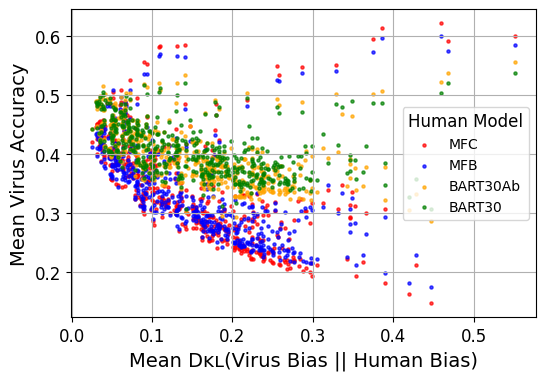

In [10]:
plt.figure(figsize=(6, 4))

# Scatter plot for each column with different colors
plt.scatter(mean_kl_divergences, virus_mean_accuracies['mfc_accuracy'], color='red', label='MFC', alpha=0.7, s=5)
plt.scatter(mean_kl_divergences, virus_mean_accuracies['mfb_accuracy'], color='blue', label='MFB', alpha=0.7, s=5)
plt.scatter(mean_kl_divergences, virus_mean_accuracies['bart30_ablation_accuracy'], color='orange', label='BART30Ab', alpha=0.7, s=5)
plt.scatter(mean_kl_divergences, virus_mean_accuracies['bart30_accuracy'], color='green', label='BART30', alpha=0.7, s=5)

# Add labels, legend, and grid
plt.xlabel('Mean Dᴋʟ(Virus Bias || Human Bias)', fontsize=14)
plt.ylabel('Mean Virus Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.title('Mean KL Divergence vs Accuracy')
plt.legend(title='Human Model', fontsize=10, title_fontsize=12)
plt.grid(True)

plt.savefig('mean_virus_accuracy_vs_mean_dkl.svg', format='svg', bbox_inches='tight')

plt.show()

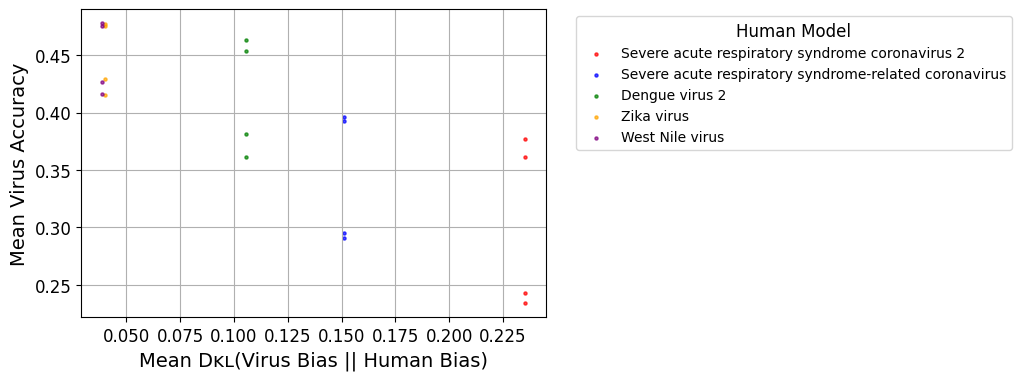

In [14]:
viruses = ['Severe acute respiratory syndrome coronavirus 2', 'Severe acute respiratory syndrome-related coronavirus', 'Dengue virus 2', 'Zika virus', 'West Nile virus']

# scatter viruses with different colors
plt.figure(figsize=(6, 4))

for virus, color in zip(viruses, ['red', 'blue', 'green', 'orange', 'purple', 'brown']):
    mask = virus_mean_accuracies.index.str.contains(virus)
    plt.scatter(mean_kl_divergences[mask], virus_mean_accuracies.loc[mask]['mfc_accuracy'], color=color, label=virus, alpha=0.7, s=5)
    plt.scatter(mean_kl_divergences[mask], virus_mean_accuracies.loc[mask]['mfb_accuracy'], color=color, alpha=0.7, s=5)
    plt.scatter(mean_kl_divergences[mask], virus_mean_accuracies.loc[mask]['bart30_ablation_accuracy'], color=color, alpha=0.7, s=5)
    plt.scatter(mean_kl_divergences[mask], virus_mean_accuracies.loc[mask]['bart30_accuracy'], color=color, alpha=0.7, s=5)

# Add labels, legend, and grid
plt.xlabel('Mean Dᴋʟ(Virus Bias || Human Bias)', fontsize=14)
plt.ylabel('Mean Virus Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.title('Mean KL Divergence vs Accuracy')
plt.legend(title='Human Model', fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# plt.savefig('mean_virus_accuracy_vs_mean_dkl_viruses.svg', format='svg', bbox_inches='tight')

plt.show()

**Plot with Smoothing**

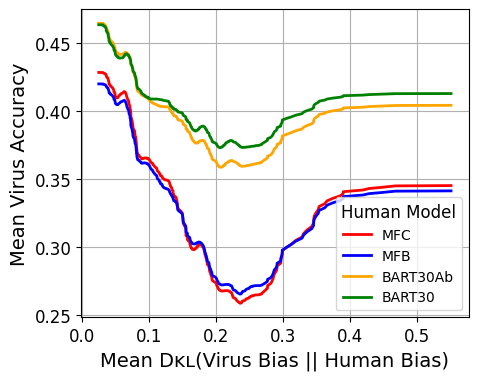

In [25]:
# Sort the data by mean_kl_divergences
sorted_indices = mean_kl_divergences.argsort()
sorted_mean_kl_divergences = mean_kl_divergences.iloc[sorted_indices]
sorted_virus_mean_accuracies = virus_mean_accuracies.iloc[sorted_indices]

# Define the window size for moving average
window_size = 15

# Plot smoothed lines for all models
plt.figure(figsize=(5, 4))
labels = ['MFC', 'MFB', 'BART30Ab', 'BART30']
colors = ['red', 'blue', 'orange', 'green']
models = ['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']

for model, color, label in zip(models, colors, labels):
    # Apply Gaussian smoothing
    smoothed_y = gaussian_filter1d(sorted_virus_mean_accuracies[model], sigma=window_size)
    
    # Plot the smoothed line
    plt.plot(sorted_mean_kl_divergences, smoothed_y, label=f'{label}', linewidth=2, color=color)

# Add labels, legend, and grid
plt.xlabel('Mean Dᴋʟ(Virus Bias || Human Bias)', fontsize=14)
plt.ylabel('Mean Virus Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.title('Gaussian Smoothed Lines of Mean KL Divergence vs Mean Accuracy', fontsize=16)
plt.legend(fontsize=10, title_fontsize=12, title='Human Model')
plt.grid(True)

plt.savefig('mean_virus_accuracy_vs_mean_dkl_smoothed.svg', format='svg', bbox_inches='tight')

plt.show()

## Mean Accuracy vs Mean GC content

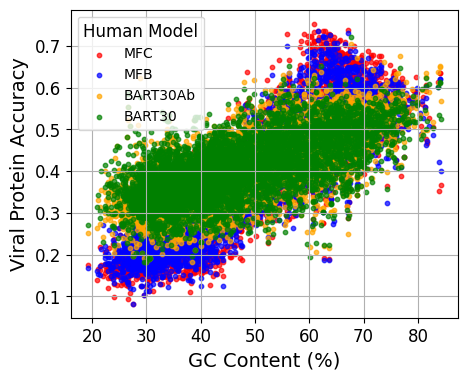

In [27]:
# Sort the data by 'GC.' column
sorted_indices = human_viruses['GC.'].argsort()
sorted_gc_content = human_viruses['GC.'].iloc[sorted_indices]
sorted_accuracies = human_viruses[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']].iloc[sorted_indices]

# Scatter plot for all models
plt.figure(figsize=(5, 4))
labels = ['MFC', 'MFB', 'BART30Ab', 'BART30']
colors = ['red', 'blue', 'orange', 'green']
models = ['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']

for model, color, label in zip(models, colors, labels):
    # Scatter plot
    plt.scatter(sorted_gc_content, sorted_accuracies[model], label=f'{label}', color=color, alpha=0.7, s=10)

# Add labels, legend, and grid
plt.xlabel('GC Content (%)', fontsize=14)
plt.ylabel('Viral Protein Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=10, title_fontsize=12, title='Human Model')
plt.grid(True)

plt.show()

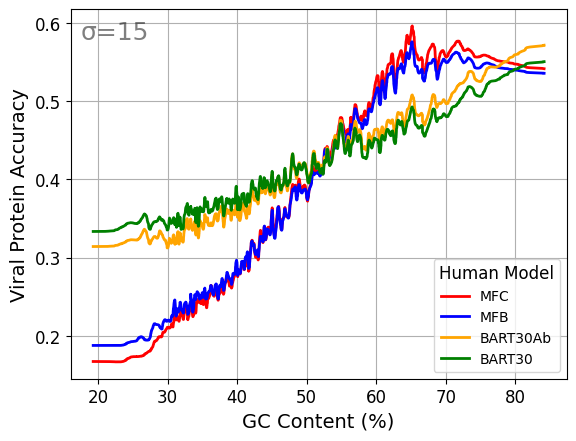

In [80]:
# Sort the data by 'GC.' column
sorted_indices = human_viruses['GC.'].argsort()
sorted_gc_content = human_viruses['GC.'].iloc[sorted_indices]
sorted_accuracies = human_viruses[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']].iloc[sorted_indices]

# Define the window size for moving average
sgma = 15

# Plot smoothed lines for all models
labels = ['MFC', 'MFB', 'BART30Ab', 'BART30']
colors = ['red', 'blue', 'orange', 'green']
models = ['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']

for model, color, label in zip(models, colors, labels):
    # Apply Gaussian smoothing
    smoothed_y = gaussian_filter1d(sorted_accuracies[model], sigma=sgma)
    
    # Plot the smoothed line
    plt.plot(sorted_gc_content, smoothed_y, label=f'{label}', linewidth=2, color=color)

# Add labels, legend, and grid
plt.xlabel('GC Content (%)', fontsize=14)
plt.ylabel('Viral Protein Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=10, title_fontsize=12, title='Human Model', loc='lower right')
plt.grid(True)

# Annotate sigma value in the top left corner
plt.text(0.02, 0.97, f'σ={sgma}', fontsize=18, ha='left', va='top', alpha=0.5, transform=plt.gca().transAxes)

# Save the figure as SVG
plt.savefig('viral_protein_accuracy_vs_gc_content_smoothed.svg', format='svg', bbox_inches='tight')

plt.show()

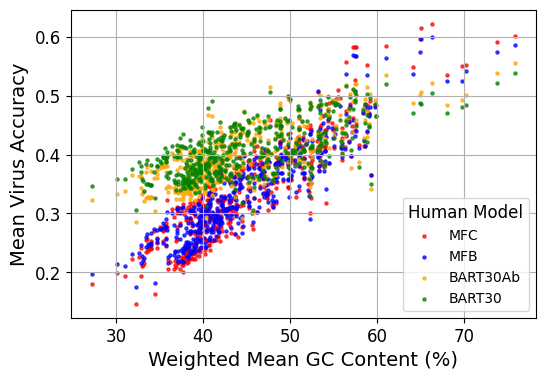

In [29]:
# Calculate the codon count (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)

# Calculate the weighted mean GC content for each unique 'Species' group
weighted_gc_content = human_viruses.groupby('Species')[['GC.', 'codon_count']].apply(
    lambda group: np.average(group['GC.'], weights=group['codon_count'])
)

# Prepare data for scatter plot
plt.figure(figsize=(6, 4))

# Scatter plot for each model with weighted GC content
plt.scatter(weighted_gc_content, virus_mean_accuracies['mfc_accuracy'], color='red', label='MFC', alpha=0.7, s=5)
plt.scatter(weighted_gc_content, virus_mean_accuracies['mfb_accuracy'], color='blue', label='MFB', alpha=0.7, s=5)
plt.scatter(weighted_gc_content, virus_mean_accuracies['bart30_ablation_accuracy'], color='orange', label='BART30Ab', alpha=0.7, s=5)
plt.scatter(weighted_gc_content, virus_mean_accuracies['bart30_accuracy'], color='green', label='BART30', alpha=0.7, s=5)

# Add labels, legend, and grid
plt.xlabel('Weighted Mean GC Content (%)', fontsize=14)
plt.ylabel('Mean Virus Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Human Model', fontsize=10, title_fontsize=12)
plt.grid(True)

plt.show()


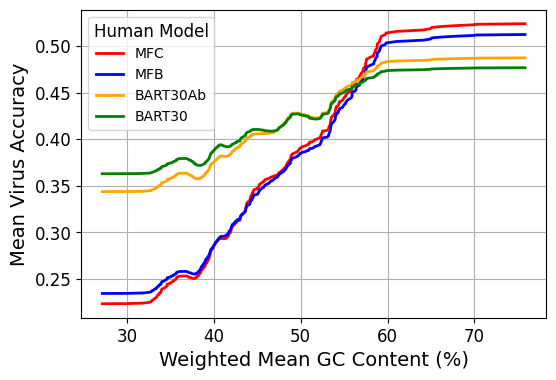

In [30]:
# Sort the data by weighted_gc_content
sorted_indices = weighted_gc_content.argsort()
sorted_gc_content = weighted_gc_content.iloc[sorted_indices]
sorted_accuracies = virus_mean_accuracies.iloc[sorted_indices]

# Apply Gaussian smoothing to the accuracies
smoothed_mfc = gaussian_filter1d(sorted_accuracies['mfc_accuracy'], sigma=window_size)
smoothed_mfb = gaussian_filter1d(sorted_accuracies['mfb_accuracy'], sigma=window_size)
smoothed_bart30_ablation = gaussian_filter1d(sorted_accuracies['bart30_ablation_accuracy'], sigma=window_size)
smoothed_bart30 = gaussian_filter1d(sorted_accuracies['bart30_accuracy'], sigma=window_size)

# Plot the smoothed lines
plt.figure(figsize=(6, 4))
plt.plot(sorted_gc_content, smoothed_mfc, color='red', label='MFC', linewidth=2)
plt.plot(sorted_gc_content, smoothed_mfb, color='blue', label='MFB', linewidth=2)
plt.plot(sorted_gc_content, smoothed_bart30_ablation, color='orange', label='BART30Ab', linewidth=2)
plt.plot(sorted_gc_content, smoothed_bart30, color='green', label='BART30', linewidth=2)

# Add labels, legend, and grid
plt.xlabel('Weighted Mean GC Content (%)', fontsize=14)
plt.ylabel('Mean Virus Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Human Model', fontsize=10, title_fontsize=12)
plt.grid(True)

plt.show()


## Virus Accuracy per Structural Component

In [103]:
temp = human_viruses.dropna(subset=['annotation'])

Xr_indices = temp[temp['annotation'].apply(lambda x: 'Xu' in x).tolist()].index

Xs_indices = temp[temp['annotation'].apply(lambda x: 'Xh' in x).tolist()].index

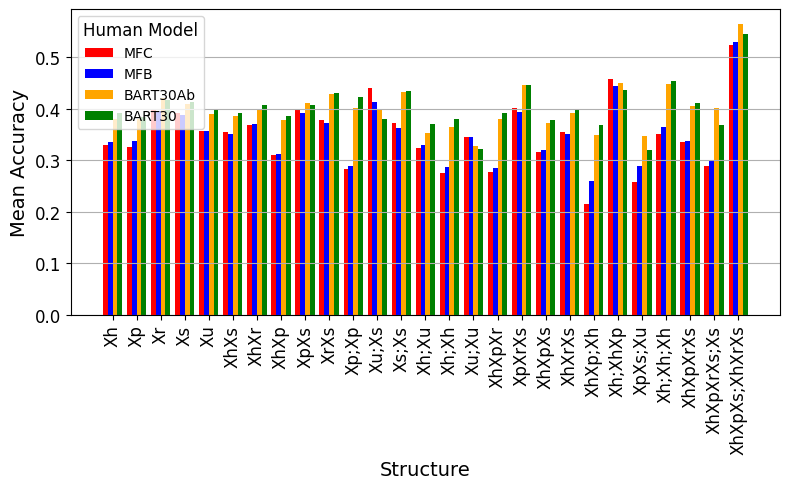

In [33]:
mean_accuracies_per_structure = human_viruses.groupby('annotation')[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']].mean()

# Get the labels and their lengths
labels = mean_accuracies_per_structure.index
label_lengths = [len(label) for label in labels]

# Sort labels by their lengths
sorted_indices = np.argsort(label_lengths)
sorted_labels = labels[sorted_indices]
sorted_mean_accuracies_per_structure = mean_accuracies_per_structure.iloc[sorted_indices]

# Bar plot with sorted labels
plt.figure(figsize=(8, 5))  # Increased figure width for better spacing
bar_width = 0.2  # Reduced bar width for more space between bars
x = np.arange(len(sorted_mean_accuracies_per_structure.index))

# Adjust bar positions for symmetry
plt.bar(x - 1.5 * bar_width, sorted_mean_accuracies_per_structure['mfc_accuracy'], width=bar_width, color='red', label='MFC')
plt.bar(x - 0.5 * bar_width, sorted_mean_accuracies_per_structure['mfb_accuracy'], width=bar_width, color='blue', label='MFB')
plt.bar(x + 0.5 * bar_width, sorted_mean_accuracies_per_structure['bart30_ablation_accuracy'], width=bar_width, color='orange', label='BART30Ab')
plt.bar(x + 1.5 * bar_width, sorted_mean_accuracies_per_structure['bart30_accuracy'], width=bar_width, color='green', label='BART30')

plt.xticks(x, sorted_labels, fontsize=12, rotation=90)
plt.legend(loc='upper left', fontsize=10, title='Human Model', title_fontsize=12)
plt.xlabel('Structure', fontsize=14)
plt.ylabel('Mean Accuracy', fontsize=14)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.tight_layout()

plt.show()


In [ ]:
human_viruses['Taxid']

,Protein.ID,Accession,VOG,annotation,Division,Taxid,Species,Organelle,X..Codons,GC.,...,bart30_predicted_codons,bart30_entropy,bart30_num_of_correct_predicted_codons,bart30_cross_entropy_loss,bart30_perplexity,bart30_accuracy,mfc_predicted_codons,mfc_accuracy,mfb_predicted_codons,mfb_accuracy
0,YP_009552823,NC_040671,VOG00934,XhXr,refseq,272636,Adeno-associated virus,genomic,649,50.49,...,ATG ACC ACA CCC ACC TAC TAT GAG CTC ATT GTG GA...,-4288.523926,298,1.153893,3.170511,0.459168,ATGACCACCCCCACCTACTACGAGCTGATCGTGGAGCTGCCCAGCG...,0.476117,ATGACCACCCCTACATATTATGAACTGATCGTGGAGCTGCCCAGCG...,0.448382
1,YP_009552824,NC_040671,VOG01499,XhXpXs,refseq,272636,Adeno-associated virus,genomic,739,51.51,...,ATG TCT GCT GCT GAC TCT GTG CCT GAC TGG CTG GA...,-4250.687012,348,1.141342,3.130969,0.470907,ATGAGCGCCGCCGACAGCGTGCCCGACTGGCTGGAGAACTTCGTGA...,0.450609,ATGAGCGCCGCCGACAGCGTGCCCGACTGGCTGGAGAACTTCGTGC...,0.445196
2,NP_049541,NC_002077,NaN,NaN,refseq,85106,Adeno-associated virus - 1,genomic,624,59.40,...,ATG CCT GGC TTC TAT GAA ATT GTG ATC AAG GTG CC...,-4274.525879,321,1.113065,3.043673,0.514423,ATGCCCGGCTTCTACGAGATCGTGATCAAGGTGCCCAGCGACCTGG...,0.637821,ATGCCCGGCTTCTACGAGATCGTGATCAAGGTGCCCAGCGACCTGG...,0.612179
3,NP_049542,NC_002077,NaN,NaN,refseq,85106,Adeno-associated virus - 1,genomic,737,53.82,...,ATG GCT GCT GAT GGC TAC CTG CCA GAC TGG CTG GA...,-4213.420410,383,1.097912,2.997901,0.519674,ATGGCCGCCGACGGCTACCTGCCCGACTGGCTGGAGGACAACCTGA...,0.488467,ATGGCCGCCGACGGCTACCTGCCCGACTGGCTGGAGGACAACCTGA...,0.472185
4,YP_680422,NC_001401,NaN,NaN,refseq,10804,Adeno-associated virus - 2,genomic,537,54.56,...,ATG CCT GGC TTC TAT GAA ATT GTG ATC AAA GTG CC...,-4290.895996,254,1.129135,3.092980,0.472998,ATGCCCGGCTTCTACGAGATCGTGATCAAGGTGCCCAGCGACCTGG...,0.549348,ATGCCCGGCTTCTACGAGATCGTGATCAAGGTGCCCAGCGACCTGG...,0.556797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6014,NP_066249,NC_002549,VOG06182,Xs,refseq,186538,Zaire ebolavirus,genomic,289,44.75,...,ATG GAG GCC AGC TAT GAG CGG GGC CGG CCC CGG GC...,-4035.790771,91,1.306037,3.691515,0.314879,ATGGAGGCCAGCTACGAGAGAGGCAGACCCAGAGCCGCCAGACAGC...,0.259516,ATGGAGGCCAGCTACGAGAGGGGCCGCCCCAGGGCCGCCCGGCAGC...,0.252595
6015,NP_066250,NC_002549,VOG06187,XhXs,refseq,186538,Zaire ebolavirus,genomic,252,42.72,...,ATG GCC AAA GCC ACT GGA AGA TAC AAC CTC ATC TC...,-4131.928223,104,1.186196,3.274600,0.412698,ATGGCCAAGGCCACCGGCAGATACAACCTGATCAGCCCCAAGAAGG...,0.309524,ATGGCCAAGGCCACCGGCCGCTACAACCTGATCAGCCCCAAGAAGG...,0.301587
6016,NP_066251,NC_002549,VOG00372,XhXrXs,refseq,186538,Zaire ebolavirus,genomic,2213,39.60,...,ATG GCC ACC CAG CAC ACC CAG TAC CCA GAT GCC CG...,-4142.313965,779,1.207667,3.345672,0.352011,ATGGCCACCCAGCACACCCAGTACCCCGACGCCAGACTGAGCAGCC...,0.263443,ATGGCCACCCAGCACACCCAGTACCCAGATGCCCGGCTGAGCAGCC...,0.268866
6017,YP_002790881,NC_012532,NaN,NaN,refseq,64320,Zika virus,genomic,3420,50.77,...,ATG AAG AAC CCC AAG GAG GAG ATC CGC CGC ATC CG...,-4183.152344,1637,1.094422,2.987456,0.478655,ATGAAGAACCCCAAGGAGGAGATCAGAAGAATCAGAATCGTGAACA...,0.431579,ATGAAGAACCCCAAGGAGGAGATCCGGCGGATCCGGATCGTGAACA...,0.416667


## Virus Accuracy vs Number of Hosts

In [12]:
','.join(['A', "B"])

'A,B'

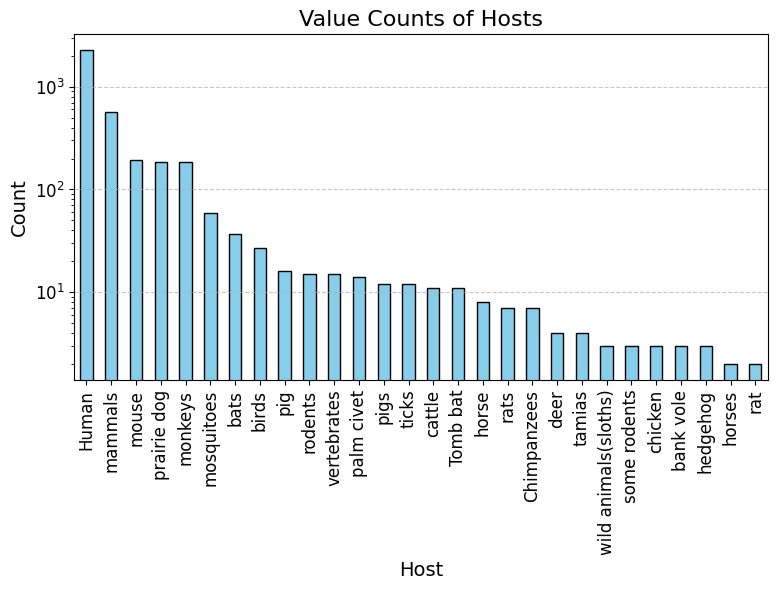

In [62]:
# Explode the 'Host' column
exploded_hosts = human_viruses.explode('Host')

# Count the occurrences of each host
host_counts = exploded_hosts['Host'].value_counts()

# Plot the histogram
plt.figure(figsize=(8, 6))
host_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Host', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Value Counts of Hosts', fontsize=16)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.yscale('log')

plt.show()

In [63]:
# Calculate the codon counts (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)

# Calculate the weighted averages for each group
mean_accuracies_per_host = human_viruses.explode('Host').groupby('Host')[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy', 'codon_count']].apply(
    lambda group: pd.Series({
        'mfc_accuracy': np.average(group['mfc_accuracy'], weights=group['codon_count']),
        'mfb_accuracy': np.average(group['mfb_accuracy'], weights=group['codon_count']),
        'bart30_ablation_accuracy': np.average(group['bart30_ablation_accuracy'], weights=group['codon_count']),
        'bart30_accuracy': np.average(group['bart30_accuracy'], weights=group['codon_count'])
    })
)

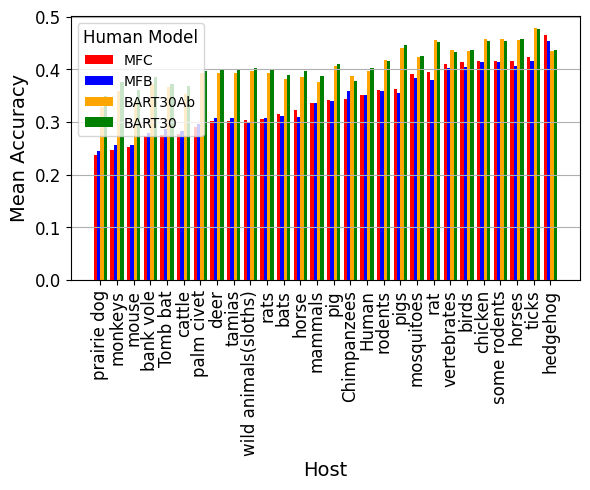

In [64]:
# Sort by mfc_accuracy
sorted_mean_accuracies_per_host = mean_accuracies_per_host.sort_values(by='mfc_accuracy', ascending=True)

# Get the sorted labels
sorted_labels = sorted_mean_accuracies_per_host.index

# Bar plot with sorted labels
plt.figure(figsize=(6, 5))
bar_width = 0.2
x = np.arange(len(sorted_mean_accuracies_per_host.index))

# Adjust bar positions for symmetry and increase spacing
plt.bar(x - 1.5 * bar_width, sorted_mean_accuracies_per_host['mfc_accuracy'], width=bar_width, color='red', label='MFC')
plt.bar(x - 0.5 * bar_width, sorted_mean_accuracies_per_host['mfb_accuracy'], width=bar_width, color='blue', label='MFB')
plt.bar(x + 0.5 * bar_width, sorted_mean_accuracies_per_host['bart30_ablation_accuracy'], width=bar_width, color='orange', label='BART30Ab')
plt.bar(x + 1.5 * bar_width, sorted_mean_accuracies_per_host['bart30_accuracy'], width=bar_width, color='green', label='BART30')

plt.xticks(x, sorted_labels, fontsize=12, rotation=90)
plt.legend(loc='upper left', fontsize=10, title='Human Model', title_fontsize=12)
plt.xlabel('Host', fontsize=14)
plt.ylabel('Mean Accuracy', fontsize=14)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.tight_layout()

plt.show()


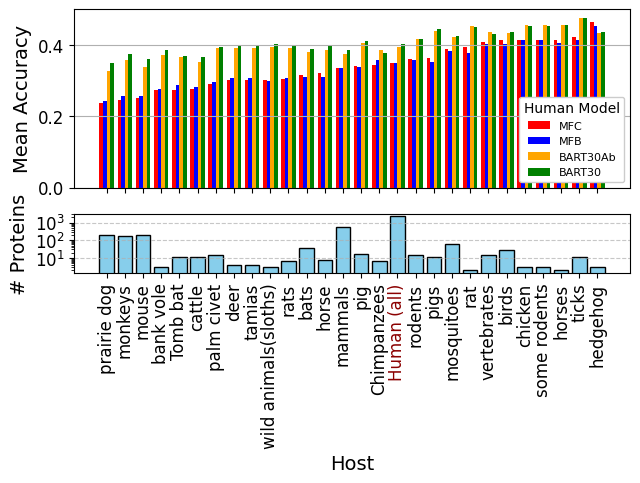

In [69]:
# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(6.5, 5), gridspec_kw={'height_ratios': [3, 1]})

# Bar plot with sorted labels
bar_width = 0.2
x = np.arange(len(sorted_mean_accuracies_per_host.index))

axes[0].bar(x - 1.5 * bar_width, sorted_mean_accuracies_per_host['mfc_accuracy'], width=bar_width, color='red', label='MFC')
axes[0].bar(x - 0.5 * bar_width, sorted_mean_accuracies_per_host['mfb_accuracy'], width=bar_width, color='blue', label='MFB')
axes[0].bar(x + 0.5 * bar_width, sorted_mean_accuracies_per_host['bart30_ablation_accuracy'], width=bar_width, color='orange', label='BART30Ab')
axes[0].bar(x + 1.5 * bar_width, sorted_mean_accuracies_per_host['bart30_accuracy'], width=bar_width, color='green', label='BART30')

axes[0].set_xticks(x)
axes[0].set_xticklabels([])
axes[0].tick_params(axis='y', labelsize=12)
legend = axes[0].legend(loc='lower right', fontsize=8, title='Human Model', title_fontsize=10, frameon=True)
legend.get_frame().set_alpha(1)
axes[0].set_ylabel('Mean Accuracy', fontsize=14)
axes[0].grid(axis='y')

# Histogram with the same bar order
host_counts = exploded_hosts['Host'].value_counts()
sorted_host_counts = host_counts.reindex(sorted_labels)

axes[1].bar(x, sorted_host_counts, color='skyblue', edgecolor='black')
axes[1].set_xticks(x)

# Replace 'Human' with 'Human (all)' in red
xtick_labels = sorted_labels.tolist()
xtick_labels[xtick_labels.index('Human')] = 'Human (all)'
axes[1].set_xticklabels(xtick_labels, fontsize=12, rotation=90)
for tick, label in zip(axes[1].get_xticks(), axes[1].get_xticklabels()):
    if label.get_text() == 'Human (all)':
        label.set_color('darkred')

axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_xlabel('Host', fontsize=14)
axes[1].set_ylabel('# Proteins', fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_yscale('log')

plt.tight_layout()

plt.savefig('mean_accuracy_per_host_and_host_counts.svg', format='svg', bbox_inches='tight')

plt.show()


## Virus Accuracy vs Tropism

In [35]:
# Calculate the codon counts (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)

# Calculate the weighted means for each group and model
virus_mean_accuracies = human_viruses.groupby('Species')[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy', 'codon_count', 'tropism']].apply(
    lambda group: pd.Series({
        'mfc_accuracy': np.average(group['mfc_accuracy'], weights=group['codon_count']),
        'mfb_accuracy': np.average(group['mfb_accuracy'], weights=group['codon_count']),
        'bart30_ablation_accuracy': np.average(group['bart30_ablation_accuracy'], weights=group['codon_count']),
        'bart30_accuracy': np.average(group['bart30_accuracy'], weights=group['codon_count']),
        'tropism': group['tropism'].iloc[0]  # each species has only one tropism
    })
)

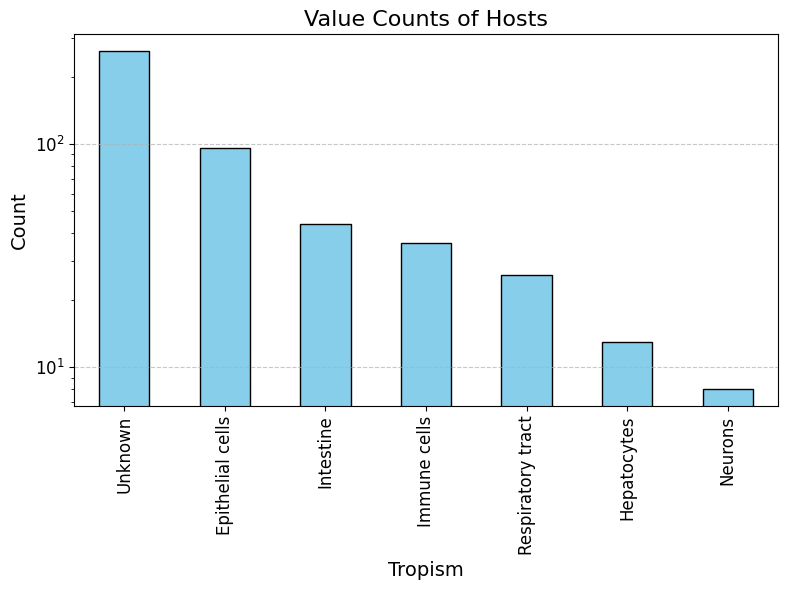

In [44]:
# Count the occurrences of each host
tropism_counts = virus_mean_accuracies['tropism'].value_counts(dropna=False)

# replace 'nan' with 'Unknown'
tropism_counts.index = tropism_counts.index.astype(str).str.replace('nan', 'Unknown')

# Plot the histogram
plt.figure(figsize=(8, 6))
tropism_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Tropism', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Value Counts of Hosts', fontsize=16)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.yscale('log')

plt.show()

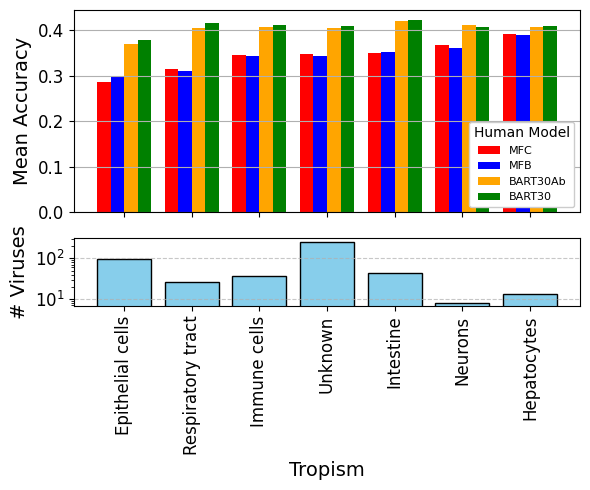

In [56]:
# Calculate the averages for each group
mean_virus_accuracies_per_tropism = virus_mean_accuracies.groupby('tropism', dropna=False)[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']].mean()

# Sort by mfc_accuracy
sorted_mean_accuracies_per_tropism = mean_virus_accuracies_per_tropism.sort_values(by='mfc_accuracy', ascending=True)

# Get the sorted labels
sorted_labels = sorted_mean_accuracies_per_tropism.index
sorted_labels = sorted_labels.astype(str).str.replace('nan', 'Unknown')

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})

# Bar plot with sorted labels
bar_width = 0.2
x = np.arange(len(sorted_mean_accuracies_per_tropism.index))

axes[0].bar(x - 1.5 * bar_width, sorted_mean_accuracies_per_tropism['mfc_accuracy'], width=bar_width, color='red', label='MFC')
axes[0].bar(x - 0.5 * bar_width, sorted_mean_accuracies_per_tropism['mfb_accuracy'], width=bar_width, color='blue', label='MFB')
axes[0].bar(x + 0.5 * bar_width, sorted_mean_accuracies_per_tropism['bart30_ablation_accuracy'], width=bar_width, color='orange', label='BART30Ab')
axes[0].bar(x + 1.5 * bar_width, sorted_mean_accuracies_per_tropism['bart30_accuracy'], width=bar_width, color='green', label='BART30')

axes[0].set_xticks(x)
axes[0].set_xticklabels([])
axes[0].tick_params(axis='y', labelsize=12)
legend = axes[0].legend(loc='lower right', fontsize=8, title='Human Model', title_fontsize=10, frameon=True)
legend.get_frame().set_alpha(1)
axes[0].set_ylabel('Mean Accuracy', fontsize=14)
axes[0].grid(axis='y')

# Histogram with the same bar order
tropism_counts = virus_mean_accuracies['tropism'].value_counts(dropna=False)
# Replace 'nan' with 'Unknown' for better readability
tropism_counts.index = tropism_counts.index.astype(str).str.replace('nan', 'Unknown')
sorted_tropism_counts = tropism_counts.reindex(sorted_labels)

axes[1].bar(x, sorted_tropism_counts, color='skyblue', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sorted_labels, fontsize=12, rotation=90)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_xlabel('Tropism', fontsize=14)
axes[1].set_ylabel('# Viruses', fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_yscale('log')

plt.tight_layout()

plt.savefig('mean_virus_accuracy_per_tropism_and_tropism_counts.svg', format='svg', bbox_inches='tight')

plt.show()


In [58]:
# Calculate the codon counts (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)

# Calculate the weighted means for each group and model
tropism_mean_accuracies = human_viruses.groupby('tropism', dropna=False)[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy', 'codon_count', 'tropism']].apply(
    lambda group: pd.Series({
        'mfc_accuracy': np.average(group['mfc_accuracy'], weights=group['codon_count']),
        'mfb_accuracy': np.average(group['mfb_accuracy'], weights=group['codon_count']),
        'bart30_ablation_accuracy': np.average(group['bart30_ablation_accuracy'], weights=group['codon_count']),
        'bart30_accuracy': np.average(group['bart30_accuracy'], weights=group['codon_count']),
    })
)

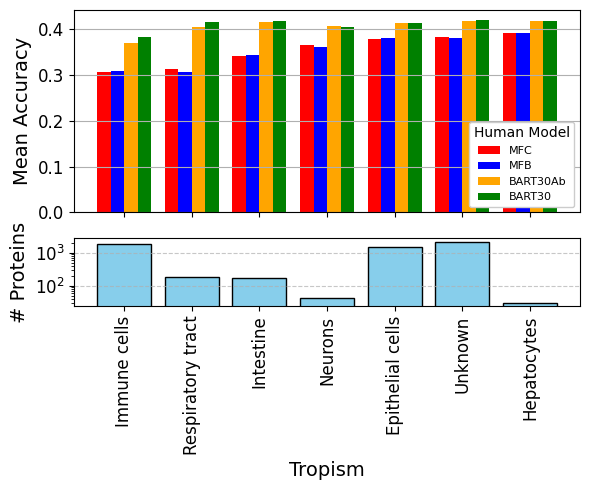

In [61]:
# Sort by mfc_accuracy
sorted_mean_accuracies_per_tropism = tropism_mean_accuracies.sort_values(by='mfc_accuracy', ascending=True)

# Get the sorted labels
sorted_labels = sorted_mean_accuracies_per_tropism.index
sorted_labels = sorted_labels.astype(str).str.replace('nan', 'Unknown')

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(6, 5), gridspec_kw={'height_ratios': [3, 1]})

# Bar plot with sorted labels
bar_width = 0.2
x = np.arange(len(sorted_mean_accuracies_per_tropism.index))

axes[0].bar(x - 1.5 * bar_width, sorted_mean_accuracies_per_tropism['mfc_accuracy'], width=bar_width, color='red', label='MFC')
axes[0].bar(x - 0.5 * bar_width, sorted_mean_accuracies_per_tropism['mfb_accuracy'], width=bar_width, color='blue', label='MFB')
axes[0].bar(x + 0.5 * bar_width, sorted_mean_accuracies_per_tropism['bart30_ablation_accuracy'], width=bar_width, color='orange', label='BART30Ab')
axes[0].bar(x + 1.5 * bar_width, sorted_mean_accuracies_per_tropism['bart30_accuracy'], width=bar_width, color='green', label='BART30')

axes[0].set_xticks(x)
axes[0].set_xticklabels([])
axes[0].tick_params(axis='y', labelsize=12)
legend = axes[0].legend(loc='lower right', fontsize=8, title='Human Model', title_fontsize=10, frameon=True)
legend.get_frame().set_alpha(1)
axes[0].set_ylabel('Mean Accuracy', fontsize=14)
axes[0].grid(axis='y')

# Histogram with the same bar order
tropism_counts = human_viruses['tropism'].value_counts(dropna=False)
# Replace 'nan' with 'Unknown' for better readability
tropism_counts.index = tropism_counts.index.astype(str).str.replace('nan', 'Unknown')
sorted_tropism_counts = tropism_counts.reindex(sorted_labels)

axes[1].bar(x, sorted_tropism_counts, color='skyblue', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sorted_labels, fontsize=12, rotation=90)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_xlabel('Tropism', fontsize=14)
axes[1].set_ylabel('# Proteins', fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_yscale('log')

plt.tight_layout()

plt.savefig('mean_protein_accuracy_per_tropism_and_tropism_counts.svg', format='svg', bbox_inches='tight')

plt.show()


## Virus Families

### Fetch Families

In [39]:
Entrez.email = "wsegalnoam@gmail.com"

# Cache to store results and avoid redundant API calls
species_to_family_cache = {}

def get_family(species_name):
    if species_name in species_to_family_cache:
        return species_to_family_cache[species_name]  # Use cached result

    handle = Entrez.esearch(db="taxonomy", term=species_name)
    record = Entrez.read(handle)
    if not record['IdList']:
        species_to_family_cache[species_name] = "Unknown"  # Cache result
        return "Unknown"  # Species not found

    taxid = record['IdList'][0]
    handle = Entrez.efetch(db="taxonomy", id=taxid)
    record = Entrez.read(handle)[0]

    for rank in record["LineageEx"]:
        if rank["Rank"] == "family":
            species_to_family_cache[species_name] = rank["ScientificName"]  # Cache result
            return rank["ScientificName"]

    species_to_family_cache[species_name] = "Unknown"  # Cache result
    return "Unknown"

In [ ]:
# Use tqdm to track progress
species_list = human_viruses['Species'].unique()
species_to_family = {}

for species in tqdm(species_list, desc="Fetching family data"):
    species_to_family[species] = get_family(species)

# Map the results back to the DataFrame
human_viruses['family'] = human_viruses['Species'].map(species_to_family)

Fetching family data: 100%|██████████| 484/484 [08:49<00:00,  1.09s/it]


In [45]:
# Filter for viruses with 'Unknown' family
unknown_family_mask = human_viruses['family'] == 'Unknown'
unknown_species = human_viruses.loc[unknown_family_mask, 'Species'].unique()

# Update the family for each species with 'Unknown' family
for species in tqdm(unknown_species, desc="Updating unknown families"):
    # Remove any strain suffix in parentheses
    cleaned_species = species.split('(')[0].strip()
    updated_family = get_family(cleaned_species)
    human_viruses.loc[human_viruses['Species'] == species, 'family'] = updated_family

Updating unknown families:   0%|          | 0/15 [00:00<?, ?it/s]

Updating unknown families: 100%|██████████| 15/15 [00:08<00:00,  1.86it/s]


In [52]:
human_viruses.loc[human_viruses['family'] == 'Unknown']['Species'].unique()

array(['Circo-like virus-Brazil hs1', 'Hudisavirus sp.',
       'Human DNA virus', 'Human feces pecovirus',
       'Severe fever with thrombocytopenia virus'], dtype=object)

In [62]:
human_viruses.loc[human_viruses['Species'] == 'Severe fever with thrombocytopenia virus', 'family'] = get_family('SFTS virus')

In [63]:
human_viruses.to_pickle(os.path.join(virus_data_path, 'human_viruses_with_family.pkl'))

## Accuracy vs. DKL Scatter with Color Groups

In [15]:
human_viruses = pd.read_pickle(os.path.join(virus_data_path, 'human_viruses_with_family.pkl'))

In [41]:
# Calculate the codon counts (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)
human_viruses['Host'] = human_viruses['Host'].apply(lambda x: ['Human'] if np.all(pd.isna(x)) else x)

# Calculate the weighted means for each group and model, and add a column for the number of rows in each group
virus_mean_accuracies = human_viruses.groupby('Species')[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy', 'codon_count', 'tropism', 'Host', 'family', 'GC.']].apply(
    lambda group: pd.Series({
        'mfc_accuracy': np.average(group['mfc_accuracy'], weights=group['codon_count']),
        'mfb_accuracy': np.average(group['mfb_accuracy'], weights=group['codon_count']),
        'bart30_ablation_accuracy': np.average(group['bart30_ablation_accuracy'], weights=group['codon_count']),
        'bart30_accuracy': np.average(group['bart30_accuracy'], weights=group['codon_count']),
        'num_rows': len(group),
        'tropism': group['tropism'].iloc[0],
        'Host': group['Host'].iloc[0],
        'family': group['family'].iloc[0],
        'total_length': group['codon_count'].sum(),
        'avg_length': group['codon_count'].sum() / len(group),
        'N': len(group),
        'GC.': np.average(group['GC.'], weights=group['codon_count'])
    })
)

### By Family

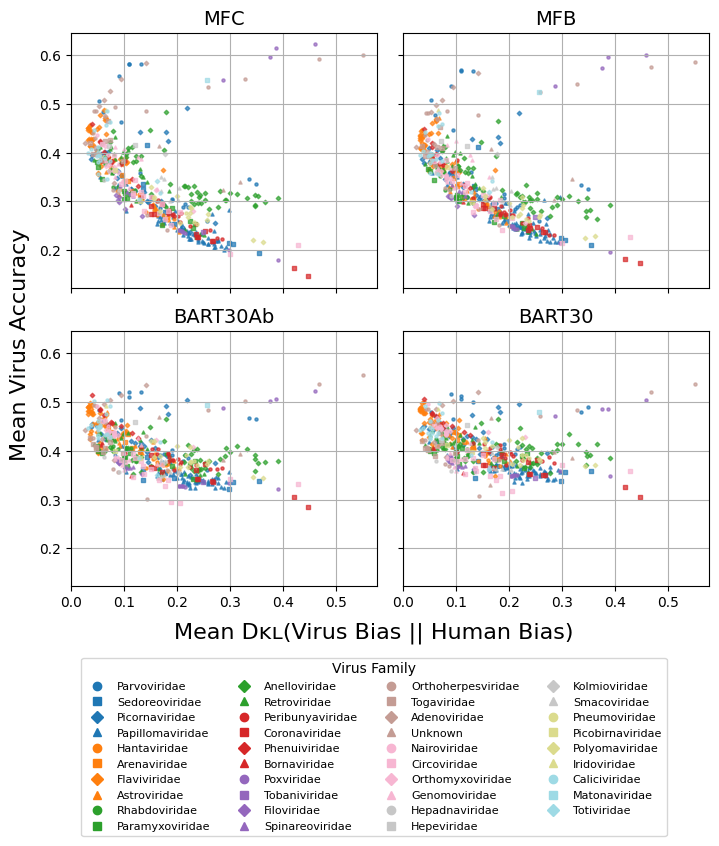

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=True, sharey=True)

models = ['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']
titles = ['MFC', 'MFB', 'BART30Ab', 'BART30']

# Generate unique styles for each family
unique_families = virus_mean_accuracies['family'].unique()
num_colors = 10
colormap = plt.get_cmap('tab20', num_colors)
marker_styles = ['o', 's', 'D', '^']
family_styles = {
    family: {
        'color': colormap(i // len(marker_styles)),
        'marker': marker_styles[i % len(marker_styles)]
    }
    for i, family in enumerate(unique_families)
}

# Scatter plot for each model
for ax, model, title in zip(axes.flat, models, titles):
    for family in unique_families:
        family_mask = virus_mean_accuracies['family'] == family
        ax.scatter(
            mean_kl_divergences[family_mask],
            virus_mean_accuracies.loc[family_mask, model],
            label=family,
            alpha=0.7,
            s=5,
            marker=family_styles[family]['marker'],
            color=family_styles[family]['color']
        )
    ax.set_title(title, fontsize=14)
    ax.grid(True)

# Add shared labels
fig.text(0.5, 0.08, 'Mean Dᴋʟ(Virus Bias || Human Bias)', ha='center', fontsize=16)
fig.text(-0.02, 0.5, 'Mean Virus Accuracy', va='center', rotation='vertical', fontsize=16)

# Create a single legend
handles = [
    plt.Line2D([0], [0], marker=family_styles[family]['marker'], color=family_styles[family]['color'], label=family, linestyle='None')
    for family in unique_families
]
fig.legend(
    handles=handles,
    title='Virus Family',
    fontsize=8,
    title_fontsize=10,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.21),
    ncol=4
)

plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.savefig('mean_virus_accuracy_vs_mean_dkl_by_family.svg', format='svg', bbox_inches='tight')

plt.show()


### By Tropism

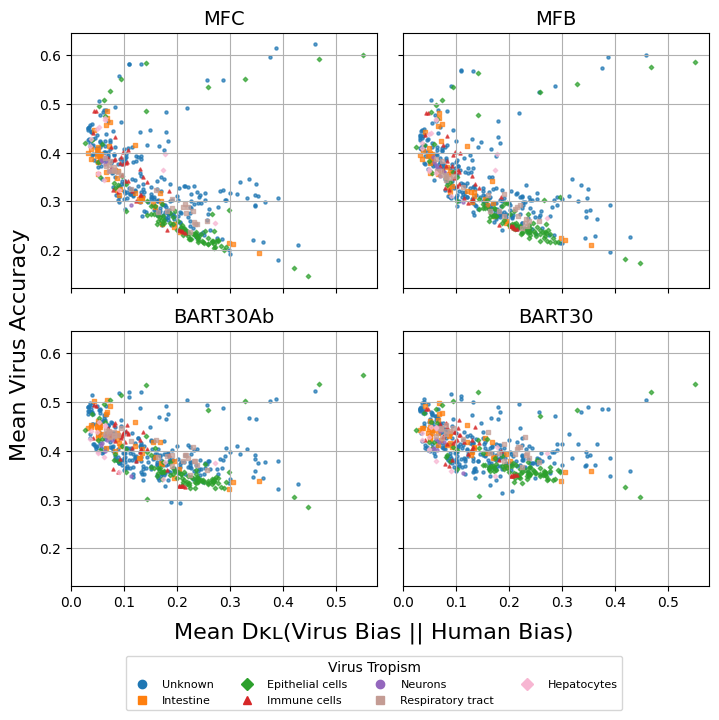

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=True, sharey=True)

models = ['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']
titles = ['MFC', 'MFB', 'BART30Ab', 'BART30']

# Generate unique styles for each tropism
unique_tropisms = virus_mean_accuracies['tropism'].fillna('Unknown').unique()
num_colors = 10
colormap = plt.get_cmap('tab20', num_colors)
marker_styles = ['o', 's', 'D', '^']
tropism_styles = {
    tropism: {
        'color': colormap(i % num_colors),
        'marker': marker_styles[i % len(marker_styles)]
    }
    for i, tropism in enumerate(unique_tropisms)
}

# Scatter plot for each model
for ax, model, title in zip(axes.flat, models, titles):
    for tropism in unique_tropisms:
        tropism_mask = virus_mean_accuracies['tropism'].fillna('Unknown') == tropism
        ax.scatter(
            mean_kl_divergences[tropism_mask],
            virus_mean_accuracies.loc[tropism_mask, model],
            label=tropism,
            alpha=0.7,
            s=5,
            marker=tropism_styles[tropism]['marker'],
            color=tropism_styles[tropism]['color']
        )
    ax.set_title(title, fontsize=14)
    ax.grid(True)

# Add shared labels
fig.text(0.5, 0.08, 'Mean Dᴋʟ(Virus Bias || Human Bias)', ha='center', fontsize=16)
fig.text(-0.02, 0.5, 'Mean Virus Accuracy', va='center', rotation='vertical', fontsize=16)

# Create a single legend
handles = [
    plt.Line2D([0], [0], marker=tropism_styles[tropism]['marker'], color=tropism_styles[tropism]['color'], label=tropism, linestyle='None')
    for tropism in unique_tropisms
]
fig.legend(
    handles=handles,
    title='Virus Tropism',
    fontsize=8,
    title_fontsize=10,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.03),
    ncol=4
)

plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.savefig('mean_virus_accuracy_vs_mean_dkl_by_tropism.svg', format='svg', bbox_inches='tight')

plt.show()


In [ ]:
# Prepare the data for the interactive plot
data = pd.DataFrame({
    'Mean KL Divergence': mean_kl_divergences,
    'MFC Accuracy': virus_mean_accuracies['mfc_accuracy'],
    'MFB Accuracy': virus_mean_accuracies['mfb_accuracy'],
    'BART30 Ablation Accuracy': virus_mean_accuracies['bart30_ablation_accuracy'],
    'BART30 Accuracy': virus_mean_accuracies['bart30_accuracy'],
    'Virus Name': mean_kl_divergences.index,
    'N': virus_mean_accuracies['num_rows'],
    'tropism': virus_mean_accuracies['tropism'],
    'Host': virus_mean_accuracies['Host'],
    'family': virus_mean_accuracies['family']
})

# Create traces for each model
trace_mfc = go.Scatter(
    x=data['Mean KL Divergence'],
    y=data['MFC Accuracy'],
    mode='markers',
    marker=dict(color='red'),
    name='MFC',
    text=data['Virus Name'] + ' (N=' + data['N'].astype(int).astype(str) + ')<br>'
        + 'Tropism: ' + data['tropism'].astype(str) + '<br>Hosts: ' + data['Host'].astype(str) + '<br>Family: ' + data['family'].astype(str)
)

trace_mfb = go.Scatter(
    x=data['Mean KL Divergence'],
    y=data['MFB Accuracy'],
    mode='markers',
    marker=dict(color='blue'),
    name='MFB',
    text=data['Virus Name'] + ' (N=' + data['N'].astype(int).astype(str) + ')<br>'
        + 'Tropism: ' + data['tropism'].astype(str) + '<br>Hosts: ' + data['Host'].astype(str) + '<br>Family: ' + data['family'].astype(str)
)

trace_bart30_ablation = go.Scatter(
    x=data['Mean KL Divergence'],
    y=data['BART30 Ablation Accuracy'],
    mode='markers',
    marker=dict(color='orange'),
    name='BART30Ab',
    text=data['Virus Name'] + ' (N=' + data['N'].astype(int).astype(str) + ')<br>'
        + 'Tropism: ' + data['tropism'].astype(str) + '<br>Hosts: ' + data['Host'].astype(str) + '<br>Family: ' + data['family'].astype(str)
)

trace_bart30 = go.Scatter(
    x=data['Mean KL Divergence'],
    y=data['BART30 Accuracy'],
    mode='markers',
    marker=dict(color='green'),
    name='BART30',
    text=data['Virus Name'] + ' (N=' + data['N'].astype(int).astype(str) + ')<br>'
        + 'Tropism: ' + data['tropism'].astype(str) + '<br>Hosts: ' + data['Host'].astype(str) + '<br>Family: ' + data['family'].astype(str)
)

# Combine traces
fig = go.Figure(data=[trace_mfc, trace_mfb, trace_bart30_ablation, trace_bart30])

# Update layout
fig.update_layout(
    title='Mean Virus Accuracy vs Mean Dᴋʟ(Virus Bias || Human Bias)',
    xaxis_title='Mean Dᴋʟ(Virus Bias || Human Bias)',
    yaxis_title='Mean Virus Accuracy',
    legend_title='Human Model',
    template='plotly_white'
)

# Show the interactive plot
# iplot(fig)
# Save the plot as an HTML file
fig.write_html('mean_virus_accuracy_vs_mean_dkl.html', auto_open=True)

### Continuous Variables 

In [123]:
def plot_virus_accuracy_vs_dkl(column, cbar_title, cmap='coolwarm', log_cbar=True, save=False, filename=None, transparent=False):
    """
    Plots mean virus accuracy vs mean Dᴋʟ(Virus Bias || Human Bias) with color mapping based on a specified column.

    Parameters:
        column (str): The column in `virus_mean_accuracies` to use for color mapping.
        cbar_title (str): Title for the colorbar.
        save (bool): Whether to save the plot as a file. Default is False.
        filename (str): Filename to save the plot if `save` is True. Default is None.
    """
    # Normalize the specified column for color mapping using LogNorm
    norm = LogNorm(vmin=virus_mean_accuracies[column].min(), vmax=virus_mean_accuracies[column].max()) if log_cbar else Normalize(vmin=virus_mean_accuracies[column].min(), vmax=virus_mean_accuracies[column].max())
    cmap = plt.get_cmap(cmap)

    fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=True, sharey=True)

    models = ['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy']
    titles = ['MFC', 'MFB', 'BART30Ab', 'BART30']

    # Scatter plot for each model
    for ax, model, title in zip(axes.flat, models, titles):
        scatter = ax.scatter(
            mean_kl_divergences,
            virus_mean_accuracies[model],
            alpha=1,
            s=5,
            color=cmap(norm(virus_mean_accuracies[column])),
        )
        ax.set_title(title, fontsize=14)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(True)
        ax.set_aspect('equal')  # Ensure each subplot is square

    # Add shared labels directly to the figure
    fig.supxlabel('Mean Dᴋʟ(Virus Bias || Human Bias)', fontsize=18, x=0.45, y=0.1)
    fig.supylabel('Mean Virus Accuracy', fontsize=18)

    # Adjust spacing between subplots
    plt.subplots_adjust(hspace=-0.25)  # Reduce the vertical space between rows

    # Create a colorbar to the right of the subplots
    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=axes.ravel().tolist(),
        label=cbar_title,
        orientation='vertical',
        pad=0.02,  # Adjust padding to avoid shifting supxlabel
        aspect=25,
        shrink=0.75,  # Adjust size of the colorbar
    )

    # fontsize of colorbar label and ticks
    cbar.ax.set_ylabel(cbar_title, fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    # Save the plot if required
    if save and filename:
        plt.savefig(filename, format='svg', bbox_inches='tight', transparent=transparent)

    plt.show()


#### By Total Amino Acid Length

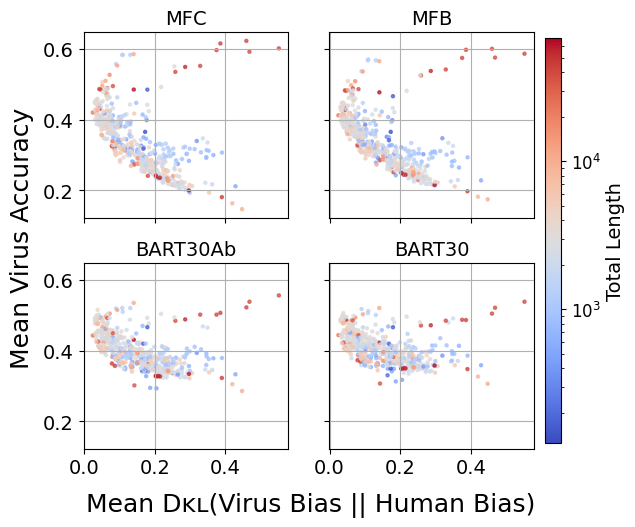

In [115]:
plot_virus_accuracy_vs_dkl(
    column='total_length',
    cbar_title='Total Length',
    save=False
)


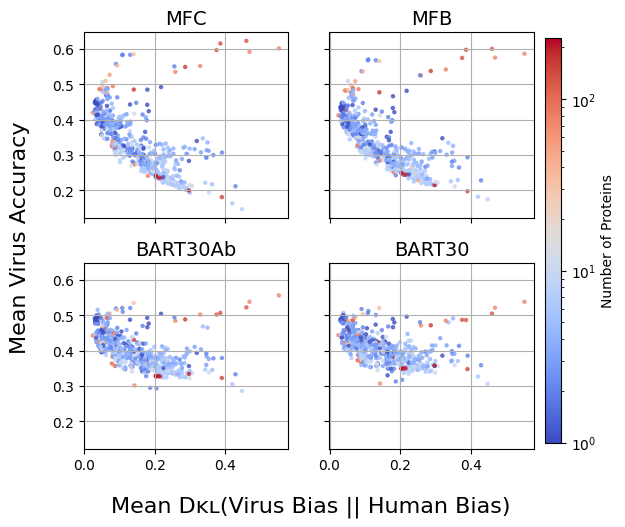

In [93]:
plot_virus_accuracy_vs_dkl(
    column='N',
    cbar_title='Number of Proteins',
    save=False
)


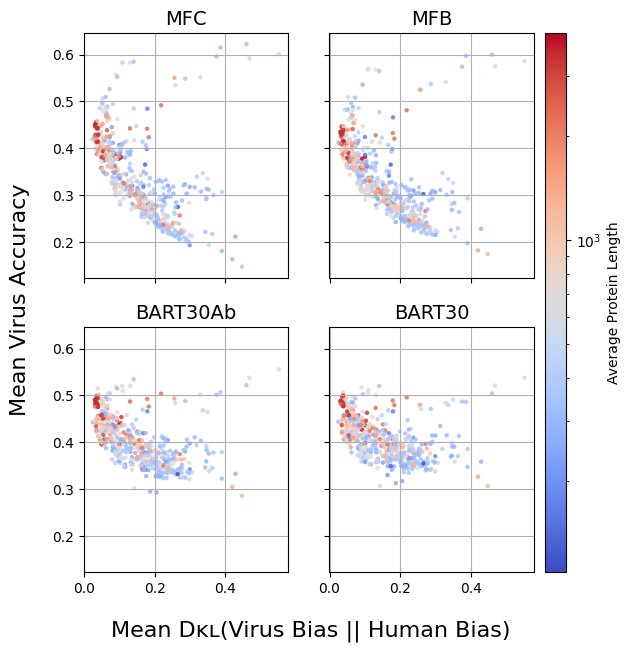

In [ ]:
plot_virus_accuracy_vs_dkl(
    column='avg_length',
    cbar_title='Average Protein Length',
    log_cbar=False,
    save=False
)

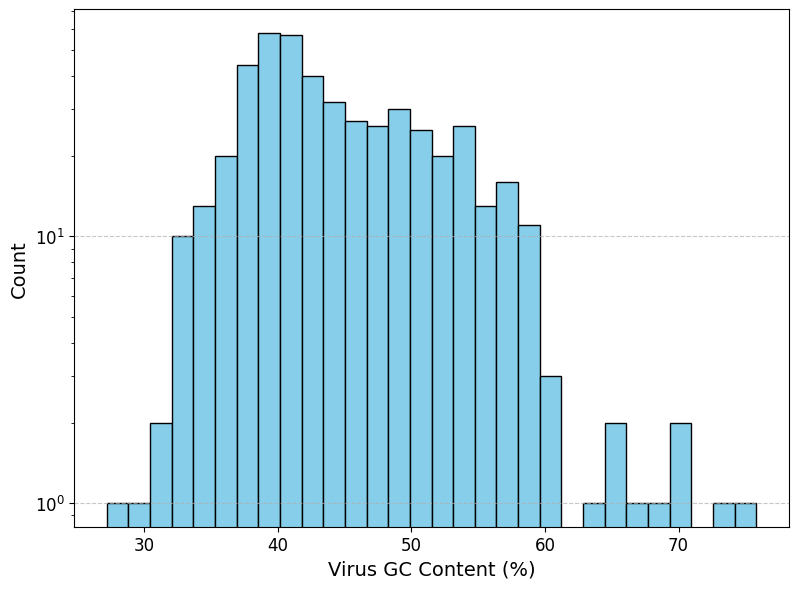

In [116]:
# histogram of virus gc content
plt.figure(figsize=(8, 6))
plt.hist(virus_mean_accuracies['GC.'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Virus GC Content (%)', fontsize=14)
plt.ylabel('Count', fontsize=14)
# plt.title('Histogram of Virus GC Content', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.yscale('log')
# plt.savefig('virus_gc_content_histogram.svg', format='svg', bbox_inches='tight')
plt.show()

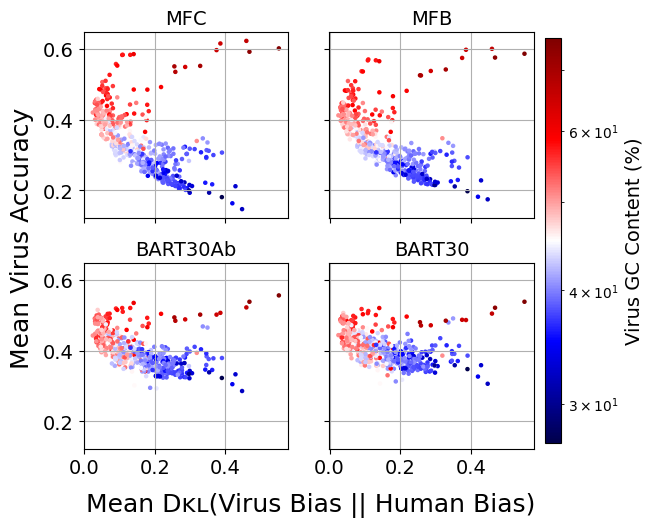

In [128]:
plot_virus_accuracy_vs_dkl(
    column='GC.',
    cbar_title='Virus GC Content (%)',
    cmap='seismic',
    log_cbar=True,
    save=True,
    filename='mean_virus_accuracy_vs_mean_dkl_by_gc_content.svg',
    transparent=False
)

## Accuracy vs. Length

### Per Protein

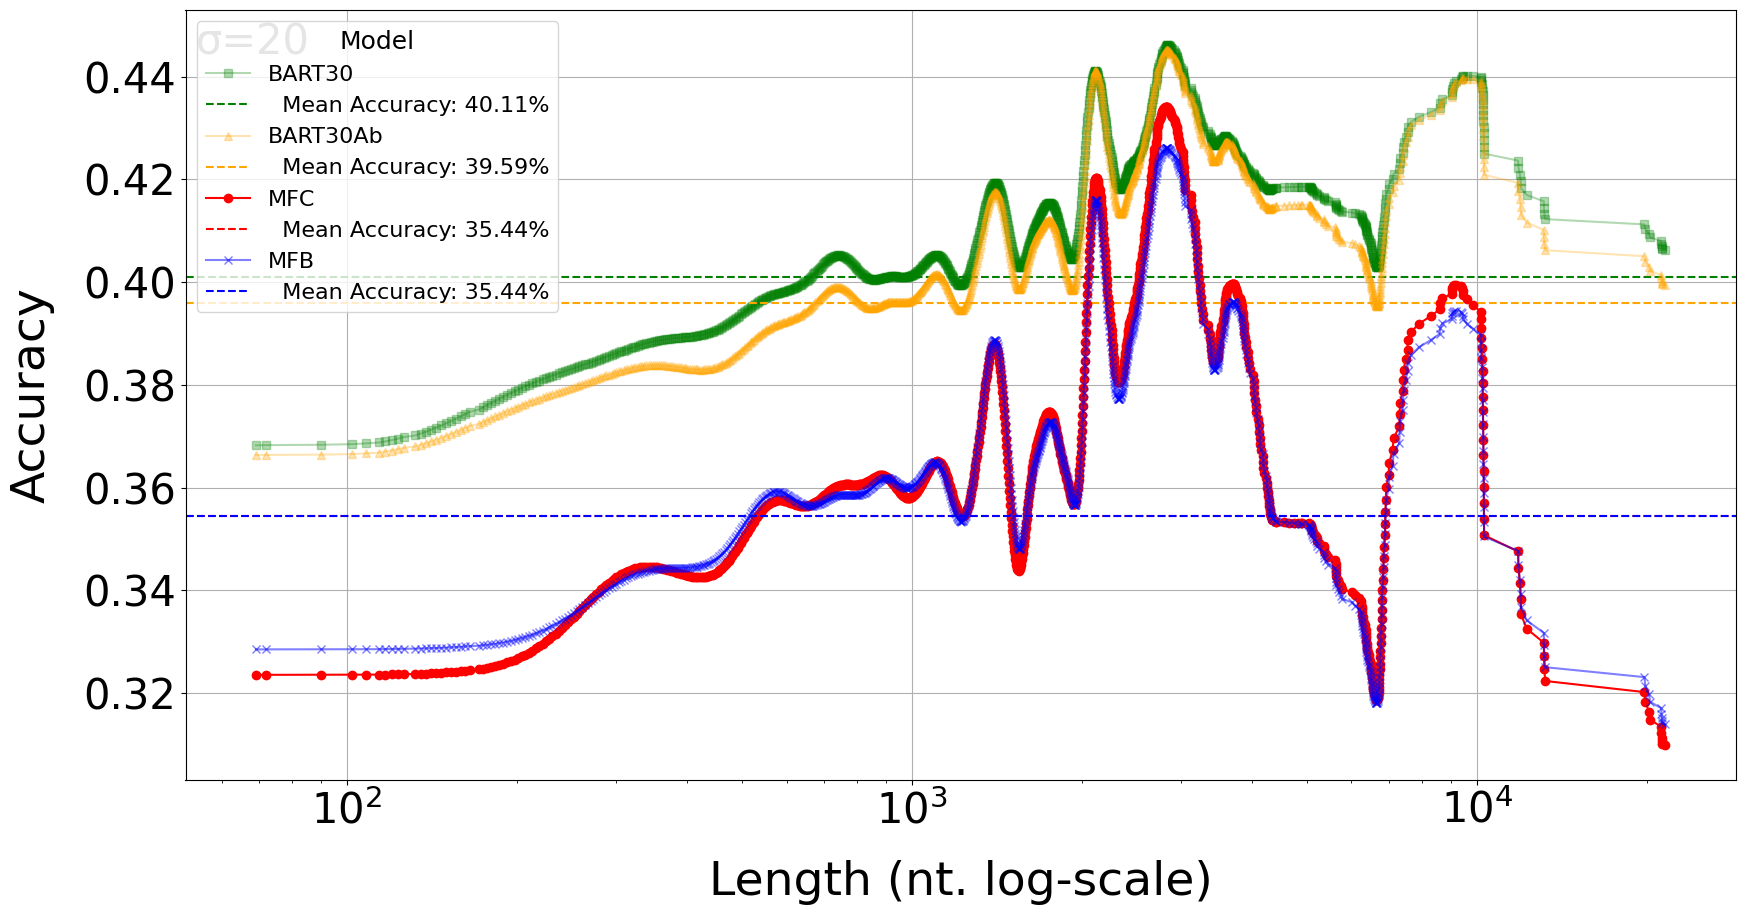

In [ ]:
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)

# sort by sequence lengths (in amino acids)
sorted_df = human_viruses.sort_values(by='length (aa)')

# Rename 'codon_count' to 'length (nt)' and multiply values by 3
sorted_df = sorted_df.rename(columns={'codon_count': 'length (nt)'})
sequence_lengths = sorted_df['length (nt)'].astype(int) * 3

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(sequence_lengths)
average_accuracies_per_length = grouped[['mfc_accuracy', 'mfb_accuracy', 'bart30_accuracy', 'bart30_ablation_accuracy']].mean()

sgma = 20

# Apply Gaussian smoothing
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_length['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_length['mfb_accuracy'], sigma=sgma)
smoothed_bart_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_accuracy'], sigma=sgma)
smoothed_bart_ablation_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_ablation_accuracy'], sigma=sgma)

avg_mfc_accuracy = np.mean(human_viruses['mfc_accuracy'])
avg_mfb_accuracy = np.mean(human_viruses['mfb_accuracy'])
avg_bart30_accuracy = np.mean(human_viruses['bart30_accuracy'])
avg_bart30_ablation_accuracy = np.mean(human_viruses['bart30_ablation_accuracy'])

plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_length.index, smoothed_bart_accuracy, marker='s', alpha=0.3, color='green', label=f'BART30')
plt.axhline(avg_bart30_accuracy, color='g', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, smoothed_bart_ablation_accuracy, marker='^', alpha=0.3, color='orange', label=f'BART30Ab')
plt.axhline(avg_bart30_ablation_accuracy, color='orange', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_ablation_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, smoothed_mfc_accuracy, marker='o', alpha=1, color='red', label=f'MFC')
plt.axhline(avg_mfc_accuracy, color='r', linestyle='--', label=f'  Mean Accuracy: {avg_mfc_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, smoothed_mfb_accuracy, marker='x', alpha=0.5, color='blue', label=f'MFB')
plt.axhline(avg_mfb_accuracy, color='b', linestyle='--', label=f'  Mean Accuracy: {avg_mfb_accuracy * 100 :.2f}%')

# plt.title(f'Model Accuracies vs. Length (nt) with Gaussian Smoothing (σ={sgma})', fontsize=20)
plt.xlabel('Length (nt. log-scale)', fontsize=34, labelpad=20)
plt.xticks(fontsize=30)
plt.xscale('log')
plt.ylabel('Accuracy', fontsize=34, labelpad=20)
plt.yticks(fontsize=30)
plt.legend(fontsize=16, title='Model', title_fontsize=18)
plt.grid(True)

# annotate sigma value in the top left corner
plt.annotate(f'σ={sgma}', xy=(0.08, 0.93), xycoords='axes fraction', fontsize=30, ha='right', va='bottom', alpha=0.5)

# plt.savefig('model_accuracies_vs_length_log_scale.svg', format='svg', bbox_inches='tight')

plt.show()

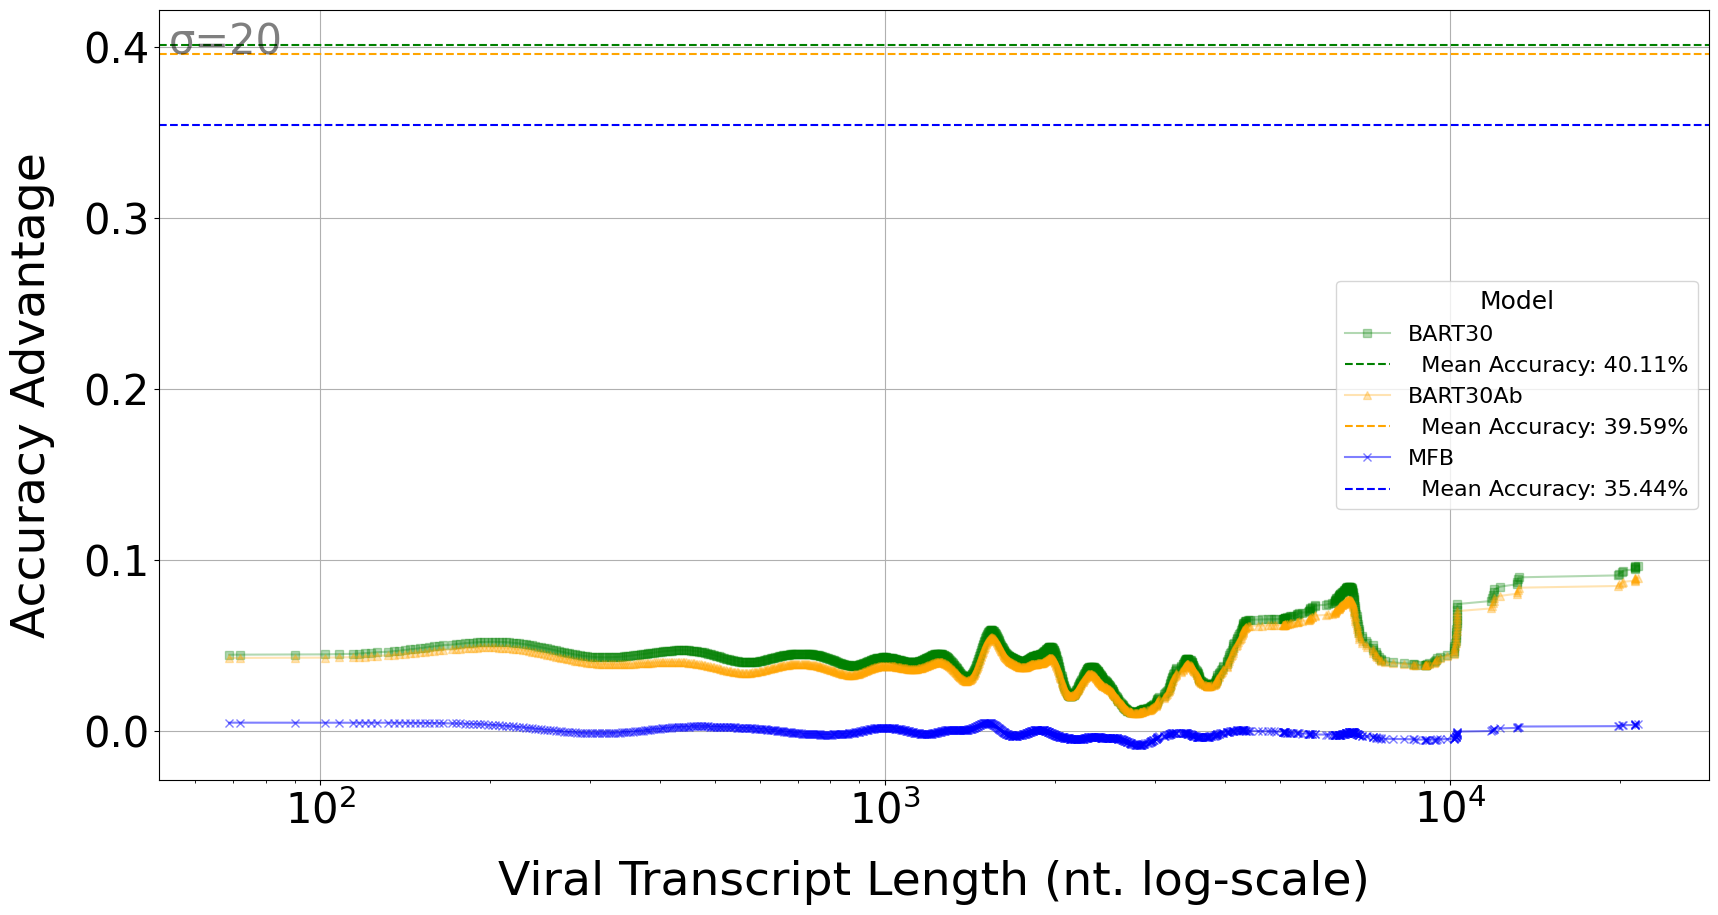

In [48]:
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)

# sort by sequence lengths (in amino acids)
sorted_df = human_viruses.sort_values(by='length (aa)')

# Rename 'codon_count' to 'length (nt)' and multiply values by 3
sorted_df = sorted_df.rename(columns={'codon_count': 'length (nt)'})
sequence_lengths = sorted_df['length (nt)'].astype(int) * 3

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(sequence_lengths)
average_accuracies_per_length = grouped[['mfc_accuracy', 'mfb_accuracy', 'bart30_accuracy', 'bart30_ablation_accuracy']].mean()

sgma = 20

# Apply Gaussian smoothing
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_length['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_length['mfb_accuracy'], sigma=sgma)
smoothed_bart_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_accuracy'], sigma=sgma)
smoothed_bart_ablation_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_ablation_accuracy'], sigma=sgma)

avg_mfc_accuracy = np.mean(human_viruses['mfc_accuracy'])
avg_mfb_accuracy = np.mean(human_viruses['mfb_accuracy'])
avg_bart30_accuracy = np.mean(human_viruses['bart30_accuracy'])
avg_bart30_ablation_accuracy = np.mean(human_viruses['bart30_ablation_accuracy'])

# Calculate the advantages
mfb_advantage = smoothed_mfb_accuracy - smoothed_mfc_accuracy
bart30_advantage = smoothed_bart_accuracy - smoothed_mfc_accuracy
bart30_ablation_advantage = smoothed_bart_ablation_accuracy - smoothed_mfc_accuracy

plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_length.index, bart30_advantage, marker='s', alpha=0.3, color='green', label=f'BART30')
plt.axhline(avg_bart30_accuracy, color='g', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, bart30_ablation_advantage, marker='^', alpha=0.3, color='orange', label=f'BART30Ab')
plt.axhline(avg_bart30_ablation_accuracy, color='orange', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_ablation_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, mfb_advantage, marker='x', alpha=0.5, color='blue', label=f'MFB')
plt.axhline(avg_mfb_accuracy, color='b', linestyle='--', label=f'  Mean Accuracy: {avg_mfb_accuracy * 100 :.2f}%')

# plt.title(f'Model Accuracies vs. Length (nt) with Gaussian Smoothing (σ={sgma})', fontsize=20)
plt.xlabel('Viral Transcript Length (nt. log-scale)', fontsize=34, labelpad=20)
plt.xticks(fontsize=30)
plt.xscale('log')
plt.ylabel('Accuracy Advantage', fontsize=34, labelpad=20)
plt.yticks(fontsize=30)
plt.legend(fontsize=16, title='Model', title_fontsize=18)
plt.grid(True)

# annotate sigma value in the top left corner
plt.annotate(f'σ={sgma}', xy=(0.08, 0.93), xycoords='axes fraction', fontsize=30, ha='right', va='bottom', alpha=0.5)

# plt.savefig('model_accuracies_vs_length_log_scale.svg', format='svg', bbox_inches='tight')

plt.show()

### Per Virus

In [37]:
# Calculate the codon counts (length of 'codon_seq' divided by 3) for each row
human_viruses['codon_count'] = human_viruses['codon_seq'].apply(lambda x: len(x) // 3)
human_viruses['Host'] = human_viruses['Host'].apply(lambda x: ['Human'] if np.all(pd.isna(x)) else x)

# Calculate the weighted means for each group and model, and add a column for the number of rows in each group
virus_mean_accuracies = human_viruses.groupby('Species')[['mfc_accuracy', 'mfb_accuracy', 'bart30_ablation_accuracy', 'bart30_accuracy', 'codon_count', 'tropism', 'Host', 'family']].apply(
    lambda group: pd.Series({
        'mfc_accuracy': np.average(group['mfc_accuracy'], weights=group['codon_count']),
        'mfb_accuracy': np.average(group['mfb_accuracy'], weights=group['codon_count']),
        'bart30_ablation_accuracy': np.average(group['bart30_ablation_accuracy'], weights=group['codon_count']),
        'bart30_accuracy': np.average(group['bart30_accuracy'], weights=group['codon_count']),
        'num_rows': len(group),
        'tropism': group['tropism'].iloc[0],
        'Host': group['Host'].iloc[0],
        'family': group['family'].iloc[0],
        'total_length': group['codon_count'].sum()
    })
)

In [41]:
virus_mean_accuracies.sort_values(by='total_length')

,mfc_accuracy,mfb_accuracy,bart30_ablation_accuracy,bart30_accuracy,num_rows,tropism,Host,family,total_length
Species,,,,,,,,,
Hepatitis C virus genotype 4,0.365079,0.365079,0.341270,0.349206,1,Hepatocytes,[Human],Flaviviridae,126
Torque teno virus 9,0.484472,0.465839,0.465839,0.465839,1,NaN,[Human],Anelloviridae,161
Sapovirus C12,0.317365,0.341317,0.419162,0.419162,1,Intestine,[Human],Caliciviridae,167
Human DNA virus,0.300000,0.290000,0.345000,0.330000,1,NaN,[Human],Unknown,200
Gemycircularvirus C1c,0.326019,0.351097,0.373041,0.366771,1,NaN,[Human],Genomoviridae,319
...,...,...,...,...,...,...,...,...,...
Camelpox virus,0.239697,0.248793,0.327882,0.349507,208,Immune cells,[Human],Poxviridae,58820
Cercopithecine betaherpesvirus 5,0.430527,0.427017,0.409383,0.407645,177,NaN,[Human],Orthoherpesviridae,59829
NY_014 poxvirus,0.199543,0.214707,0.333665,0.357855,196,NaN,[Human],Poxviridae,61265


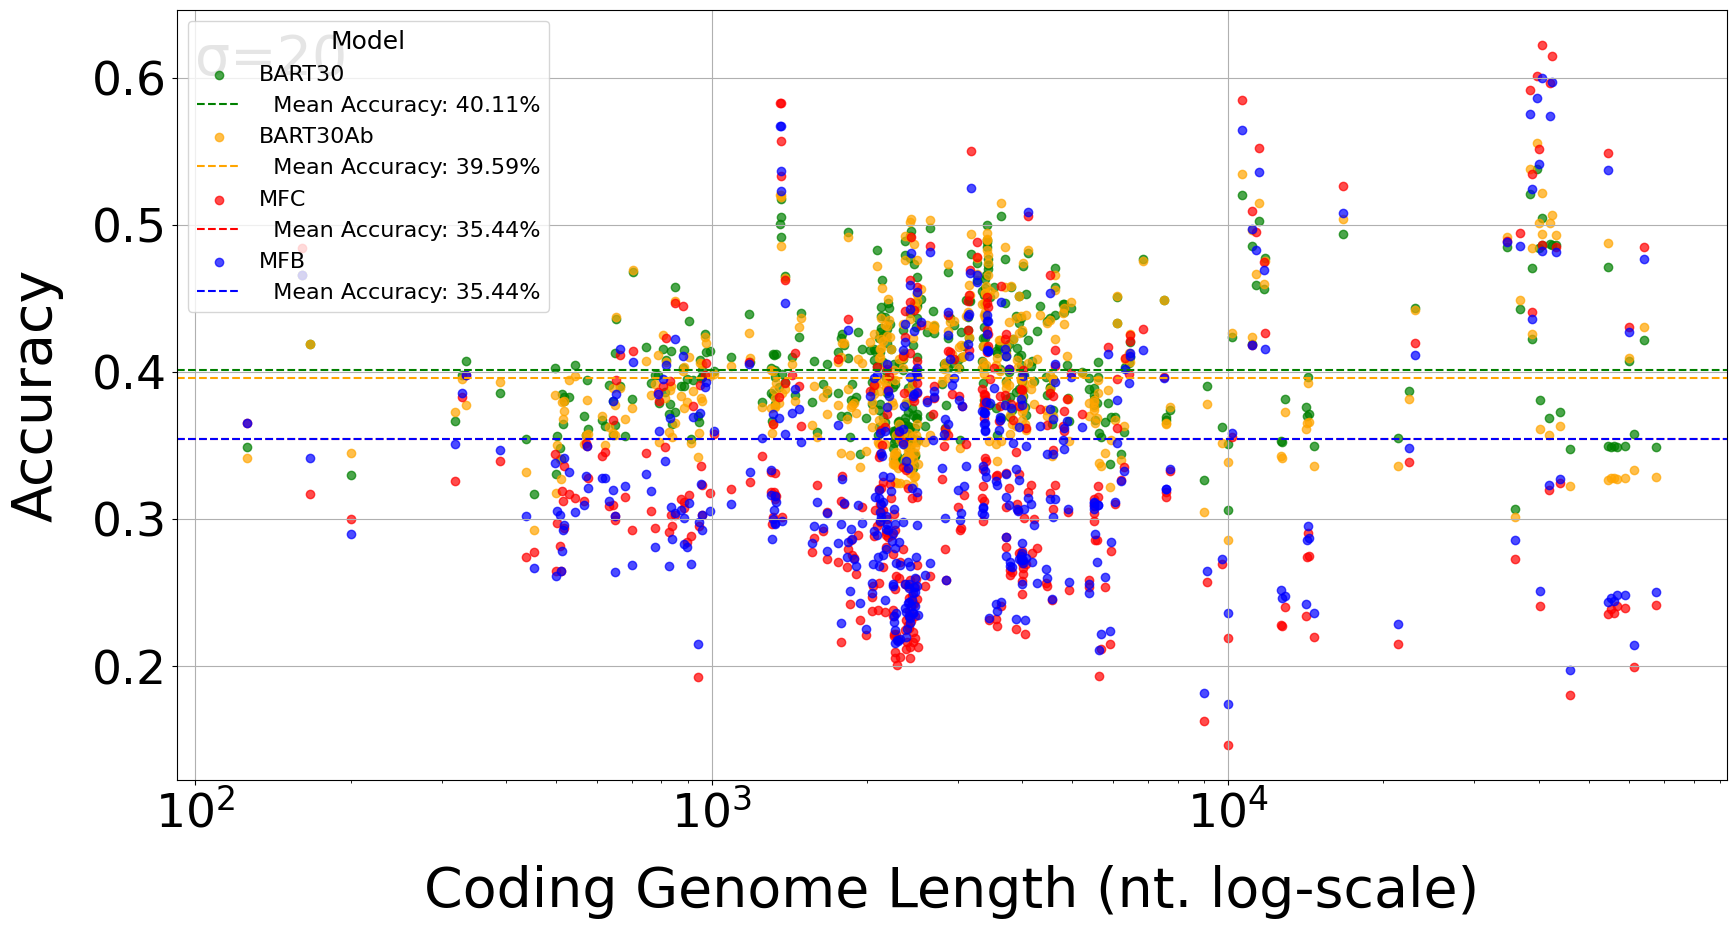

In [57]:
# sort by sequence lengths (in amino acids)
sorted_df = virus_mean_accuracies.sort_values(by='total_length')

# Rename 'codon_count' to 'length (nt)'
sorted_df = sorted_df.rename(columns={'total_length': 'length (nt)'})
sequence_lengths = sorted_df['length (nt)'].astype(int)

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(sequence_lengths)
average_accuracies_per_length = grouped[['mfc_accuracy', 'mfb_accuracy', 'bart30_accuracy', 'bart30_ablation_accuracy']].mean()

sgma = 20

plt.figure(figsize=(20, 10))

# Scatter plot for BART30
plt.scatter(average_accuracies_per_length.index, average_accuracies_per_length['bart30_accuracy'], alpha=0.7, color='green', label=f'BART30')
plt.axhline(avg_bart30_accuracy, color='g', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_accuracy * 100 :.2f}%')

# Scatter plot for BART30Ab
plt.scatter(average_accuracies_per_length.index, average_accuracies_per_length['bart30_ablation_accuracy'], alpha=0.7, color='orange', label=f'BART30Ab')
plt.axhline(avg_bart30_ablation_accuracy, color='orange', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_ablation_accuracy * 100 :.2f}%')

# Scatter plot for MFC
plt.scatter(average_accuracies_per_length.index, average_accuracies_per_length['mfc_accuracy'], alpha=0.7, color='red', label=f'MFC')
plt.axhline(avg_mfc_accuracy, color='r', linestyle='--', label=f'  Mean Accuracy: {avg_mfc_accuracy * 100 :.2f}%')

# Scatter plot for MFB
plt.scatter(average_accuracies_per_length.index, average_accuracies_per_length['mfb_accuracy'], alpha=0.7, color='blue', label=f'MFB')
plt.axhline(avg_mfb_accuracy, color='b', linestyle='--', label=f'  Mean Accuracy: {avg_mfb_accuracy * 100 :.2f}%')

plt.xlabel('Coding Genome Length (nt. log-scale)', fontsize=40, labelpad=20)
plt.xticks(fontsize=34)
plt.xscale('log')
plt.ylabel('Accuracy', fontsize=40, labelpad=20)
plt.yticks(fontsize=34)
plt.legend(fontsize=16, title='Model', title_fontsize=18)
plt.grid(True)

# Annotate sigma value in the top left corner
plt.annotate(f'σ={sgma}', xy=(0.11, 0.9), xycoords='axes fraction', fontsize=40, ha='right', va='bottom', alpha=0.5)

# plt.savefig('model_accuracies_vs_genome_length_log_scale_scatter.svg', format='svg', bbox_inches='tight')

plt.show()

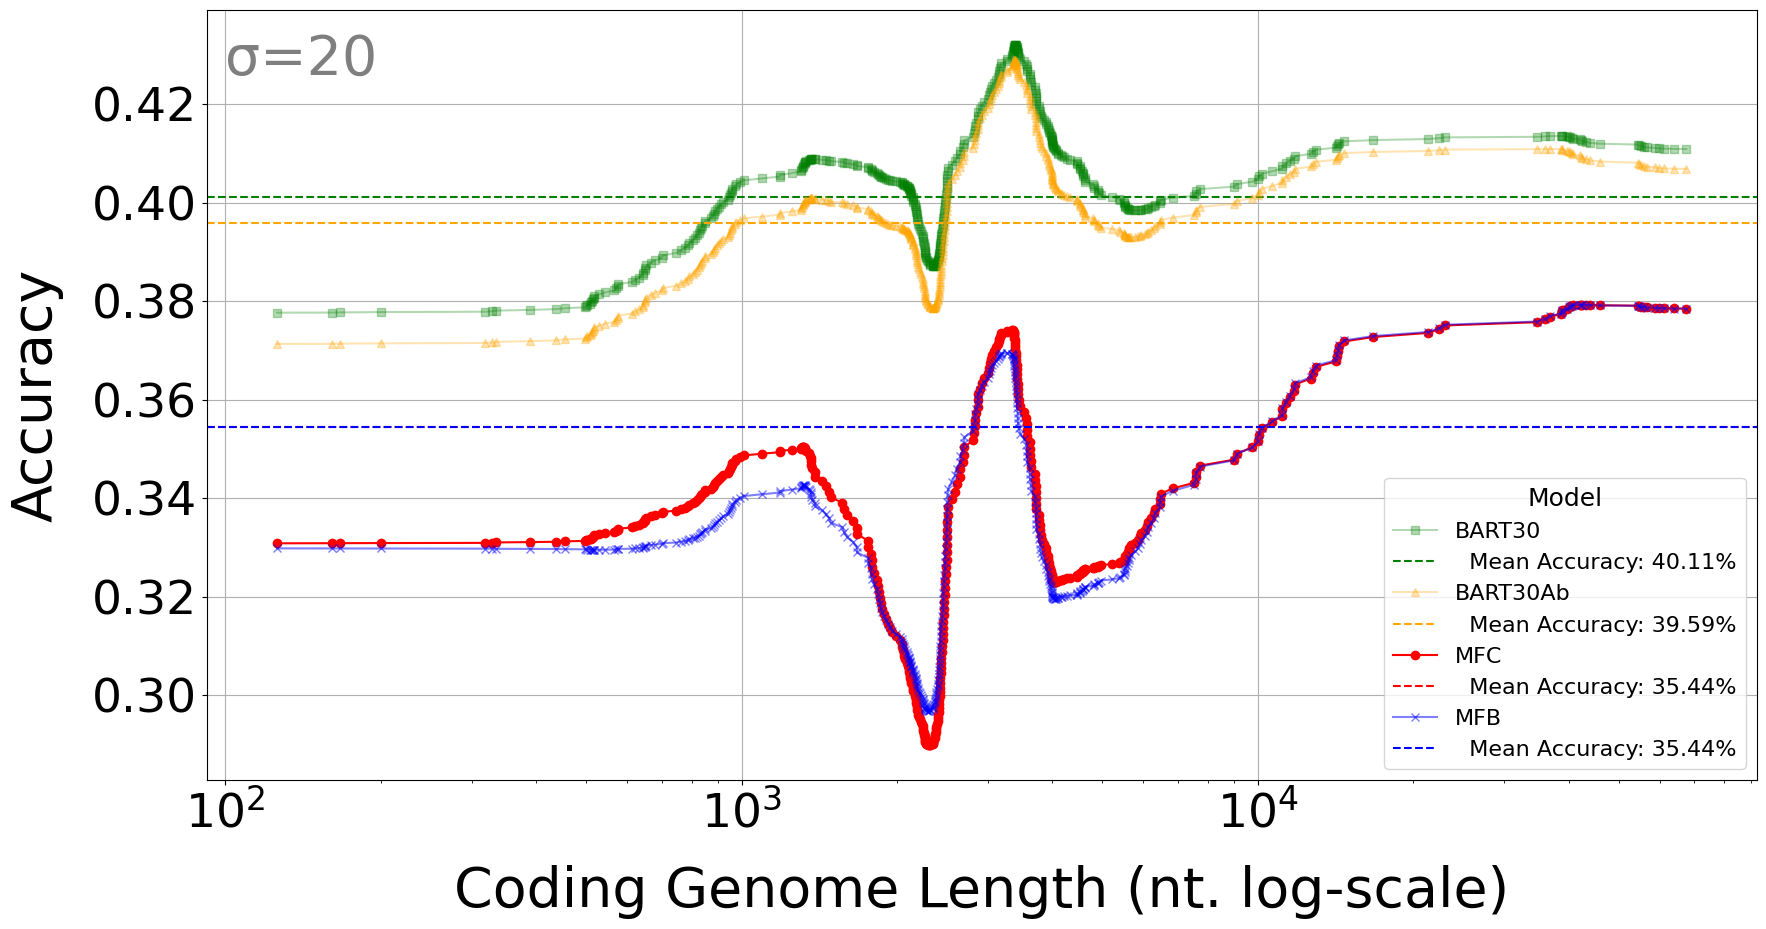

In [56]:
# sort by sequence lengths (in amino acids)
sorted_df = virus_mean_accuracies.sort_values(by='total_length')

# Rename 'codon_count' to 'length (nt)'
sorted_df = sorted_df.rename(columns={'total_length': 'length (nt)'})
sequence_lengths = sorted_df['length (nt)'].astype(int)

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(sequence_lengths)
average_accuracies_per_length = grouped[['mfc_accuracy', 'mfb_accuracy', 'bart30_accuracy', 'bart30_ablation_accuracy']].mean()

sgma = 20

# Apply Gaussian smoothing
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_length['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_length['mfb_accuracy'], sigma=sgma)
smoothed_bart_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_accuracy'], sigma=sgma)
smoothed_bart_ablation_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_ablation_accuracy'], sigma=sgma)

avg_mfc_accuracy = np.mean(human_viruses['mfc_accuracy'])
avg_mfb_accuracy = np.mean(human_viruses['mfb_accuracy'])
avg_bart30_accuracy = np.mean(human_viruses['bart30_accuracy'])
avg_bart30_ablation_accuracy = np.mean(human_viruses['bart30_ablation_accuracy'])

plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_length.index, smoothed_bart_accuracy, marker='s', alpha=0.3, color='green', label=f'BART30')
plt.axhline(avg_bart30_accuracy, color='g', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, smoothed_bart_ablation_accuracy, marker='^', alpha=0.3, color='orange', label=f'BART30Ab')
plt.axhline(avg_bart30_ablation_accuracy, color='orange', linestyle='--', label=f'  Mean Accuracy: {avg_bart30_ablation_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, smoothed_mfc_accuracy, marker='o', alpha=1, color='red', label=f'MFC')
plt.axhline(avg_mfc_accuracy, color='r', linestyle='--', label=f'  Mean Accuracy: {avg_mfc_accuracy * 100 :.2f}%')

plt.plot(average_accuracies_per_length.index, smoothed_mfb_accuracy, marker='x', alpha=0.5, color='blue', label=f'MFB')
plt.axhline(avg_mfb_accuracy, color='b', linestyle='--', label=f'  Mean Accuracy: {avg_mfb_accuracy * 100 :.2f}%')

# plt.title(f'Model Accuracies vs. Length (nt) with Gaussian Smoothing (σ={sgma})', fontsize=20)
plt.xlabel('Coding Genome Length (nt. log-scale)', fontsize=40, labelpad=20)
plt.xticks(fontsize=34)
plt.xscale('log')
plt.ylabel('Accuracy', fontsize=40, labelpad=20)
plt.yticks(fontsize=34)
plt.legend(fontsize=16, title='Model', title_fontsize=18)
plt.grid(True)

# annotate sigma value in the top left corner
plt.annotate(f'σ={sgma}', xy=(0.11, 0.9), xycoords='axes fraction', fontsize=40, ha='right', va='bottom', alpha=0.5)

plt.savefig('model_accuracies_vs_genome_length_log_scale.svg', format='svg', bbox_inches='tight')

plt.show()

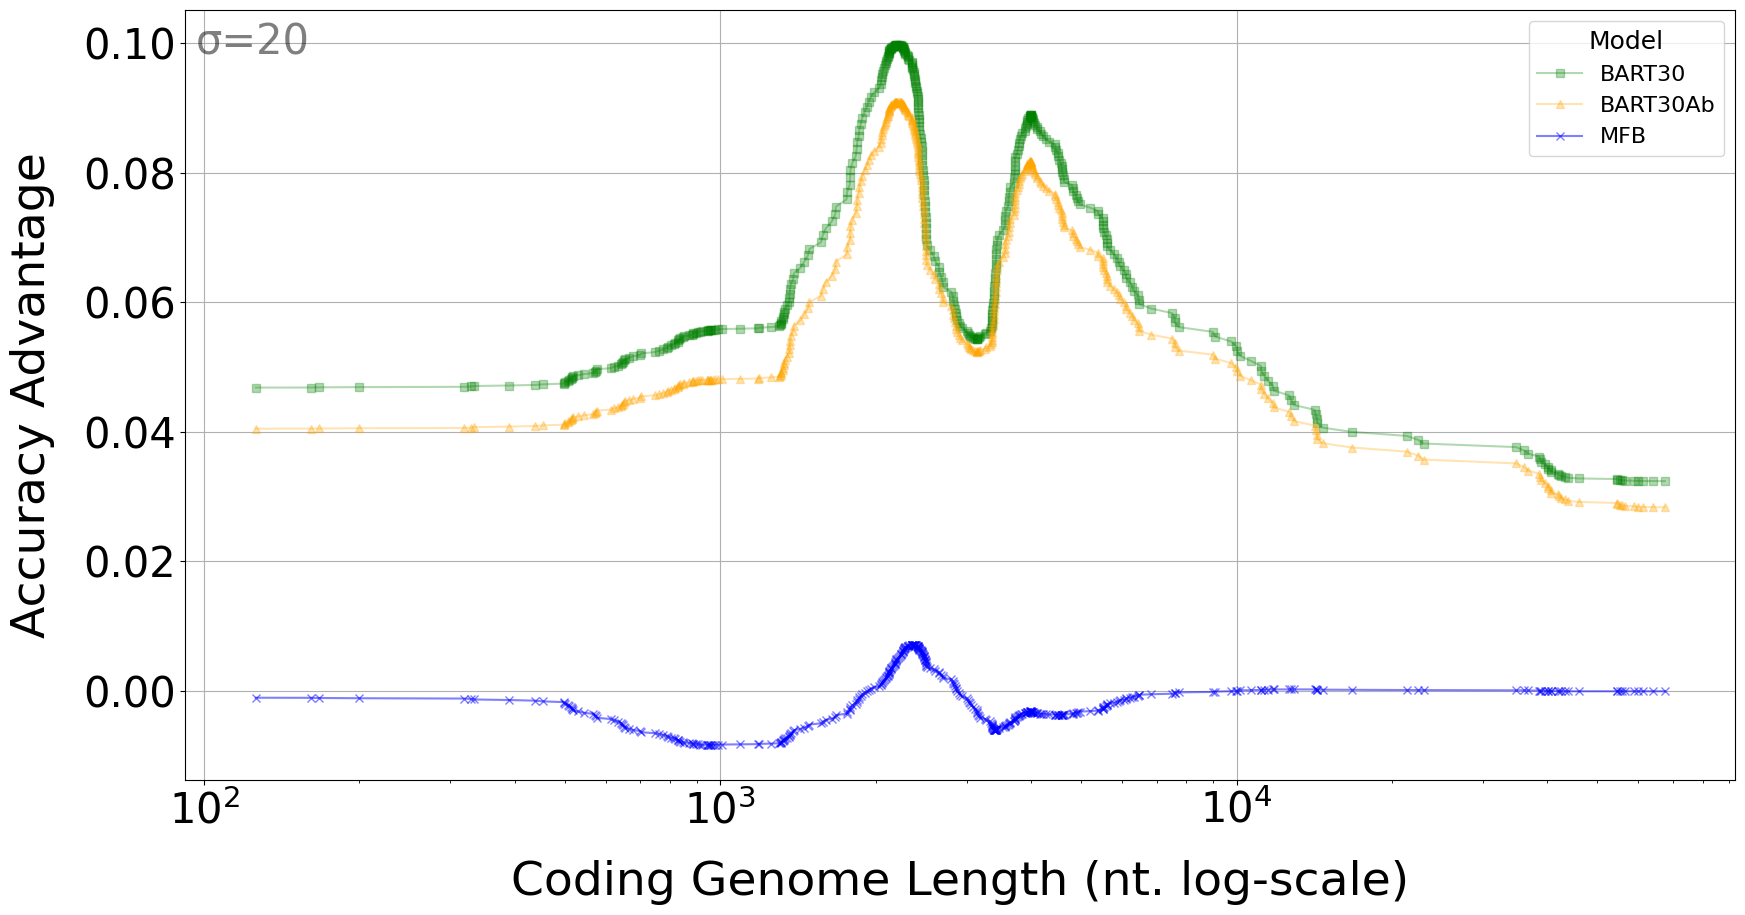

In [49]:
# sort by sequence lengths (in amino acids)
sorted_df = virus_mean_accuracies.sort_values(by='total_length')

# Rename 'codon_count' to 'length (nt)'
sorted_df = sorted_df.rename(columns={'total_length': 'length (nt)'})
sequence_lengths = sorted_df['length (nt)'].astype(int)

# group by sequence lengths and calculate the average of the accuracy columns
grouped = sorted_df.groupby(sequence_lengths)
average_accuracies_per_length = grouped[['mfc_accuracy', 'mfb_accuracy', 'bart30_accuracy', 'bart30_ablation_accuracy']].mean()

sgma = 20

# Apply Gaussian smoothing
smoothed_mfc_accuracy = gaussian_filter1d(average_accuracies_per_length['mfc_accuracy'], sigma=sgma)
smoothed_mfb_accuracy = gaussian_filter1d(average_accuracies_per_length['mfb_accuracy'], sigma=sgma)
smoothed_bart_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_accuracy'], sigma=sgma)
smoothed_bart_ablation_accuracy = gaussian_filter1d(average_accuracies_per_length['bart30_ablation_accuracy'], sigma=sgma)

avg_mfc_accuracy = np.mean(human_viruses['mfc_accuracy'])
avg_mfb_accuracy = np.mean(human_viruses['mfb_accuracy'])
avg_bart30_accuracy = np.mean(human_viruses['bart30_accuracy'])
avg_bart30_ablation_accuracy = np.mean(human_viruses['bart30_ablation_accuracy'])

# advantages over mfc
mfb_advantage = smoothed_mfb_accuracy - smoothed_mfc_accuracy
bart30_advantage = smoothed_bart_accuracy - smoothed_mfc_accuracy
bart30_ablation_advantage = smoothed_bart_ablation_accuracy - smoothed_mfc_accuracy

plt.figure(figsize=(20, 10))

plt.plot(average_accuracies_per_length.index, bart30_advantage, marker='s', alpha=0.3, color='green', label=f'BART30')

plt.plot(average_accuracies_per_length.index, bart30_ablation_advantage, marker='^', alpha=0.3, color='orange', label=f'BART30Ab')

plt.plot(average_accuracies_per_length.index, mfb_advantage, marker='x', alpha=0.5, color='blue', label=f'MFB')

# plt.title(f'Model Accuracies vs. Length (nt) with Gaussian Smoothing (σ={sgma})', fontsize=20)
plt.xlabel('Coding Genome Length (nt. log-scale)', fontsize=34, labelpad=20)
plt.xticks(fontsize=30)
plt.xscale('log')
plt.ylabel('Accuracy Advantage', fontsize=34, labelpad=20)
plt.yticks(fontsize=30)
plt.legend(fontsize=16, title='Model', title_fontsize=18)
plt.grid(True)

# annotate sigma value in the top left corner
plt.annotate(f'σ={sgma}', xy=(0.08, 0.93), xycoords='axes fraction', fontsize=30, ha='right', va='bottom', alpha=0.5)

# plt.savefig('model_accuracies_vs_length_log_scale.svg', format='svg', bbox_inches='tight')

plt.show()